In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
# pd.read_csv('data/train.csv').to_parquet('data/train.parquet', index=False)
# pd.read_csv('data/test.csv').to_parquet('data/test.parquet', index=False)

In [3]:
os.listdir()

['data', 'eda.ipynb']

In [4]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
original = pd.read_parquet('data/original.parquet')

In [5]:
original.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
original.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [9]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [10]:
cat_cols = [i for i in train.columns if train[i].dtype == 'object']
for i in cat_cols:
    print('---------------')
    print('---------------')
    if i == 'Churn':
        continue
    print(train[[i, 'Churn']].value_counts())
    

---------------
---------------
gender  Churn
Female  No       230615
Male    No       229762
Female  Yes       68123
Male    Yes       65694
Name: count, dtype: int64
---------------
---------------
Partner  Churn
Yes      No       268137
No       No       192240
         Yes       92400
Yes      Yes       41417
Name: count, dtype: int64
---------------
---------------
Dependents  Churn
No          No       293636
Yes         No       166741
No          Yes      120726
Yes         Yes       13091
Name: count, dtype: int64
---------------
---------------
PhoneService  Churn
Yes           No       430180
              Yes      127713
No            No        30197
              Yes        6104
Name: count, dtype: int64
---------------
---------------
MultipleLines     Churn
No                No       231717
Yes               No       198463
                  Yes       76046
No                Yes       51667
No phone service  No        30197
                  Yes        6104
Name: count, 

In [11]:
train['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [12]:
df = train.copy()
df['target'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['Churn', 'id'])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,0
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,0
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,0
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,0


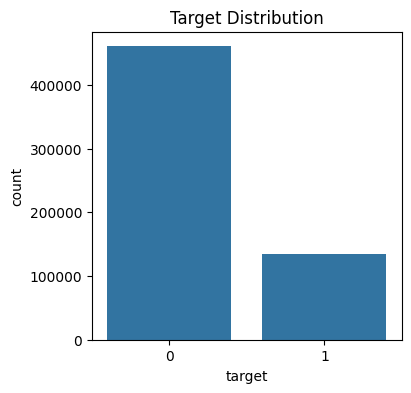

In [13]:
plt.figure(figsize=(4,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()


In [25]:
def plot_binned_target(df, feature, bins=50):
    temp = df[[feature, "target"]].copy()
    temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    
    grouped = temp.groupby("bin")["target"].mean()
    
    plt.figure(figsize=(8,4))
    grouped.plot(marker="o")
    plt.ylabel("P(Heart Disease = Presence)")
    plt.title(f"{feature} vs Heart Disease (Binned)")
    plt.xticks(rotation=45)
    plt.show()


In [14]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

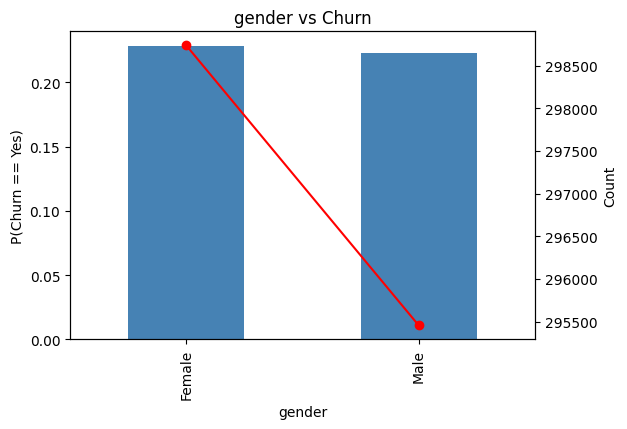

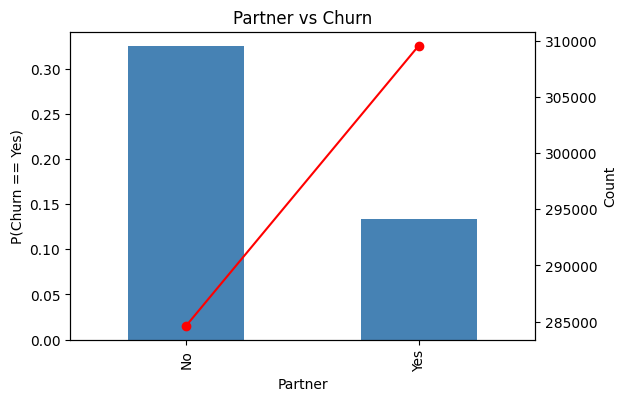

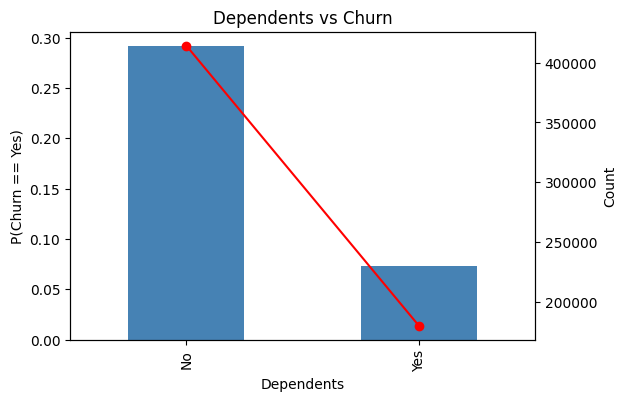

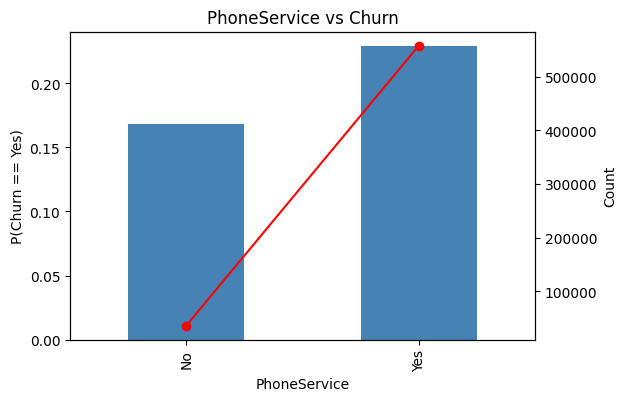

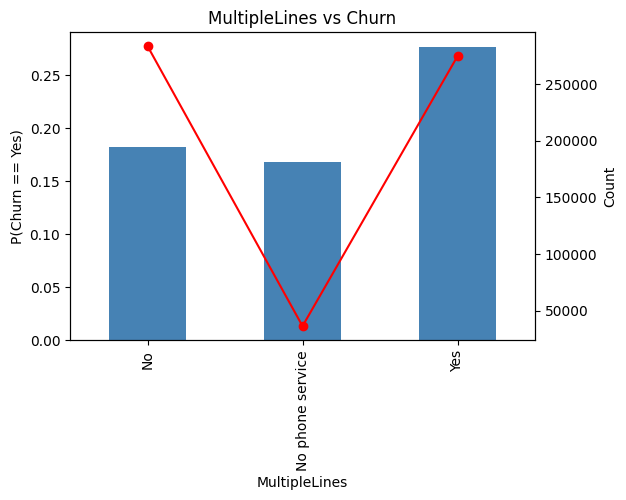

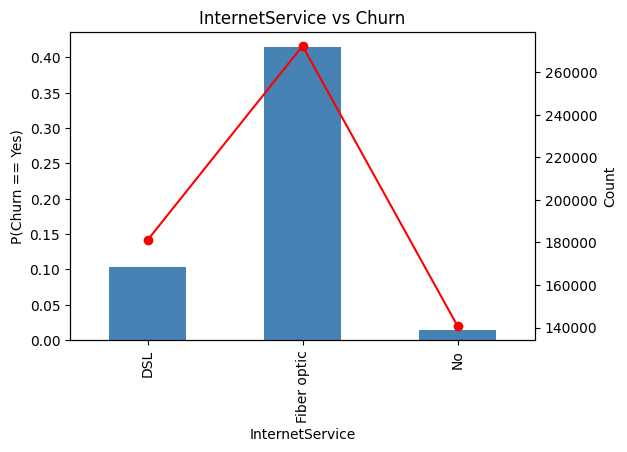

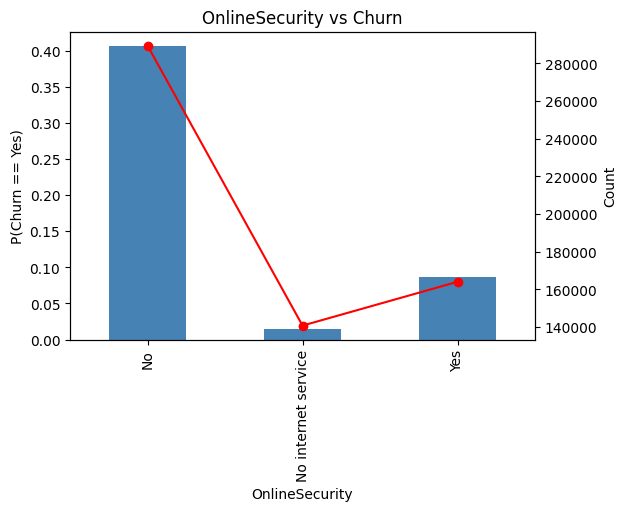

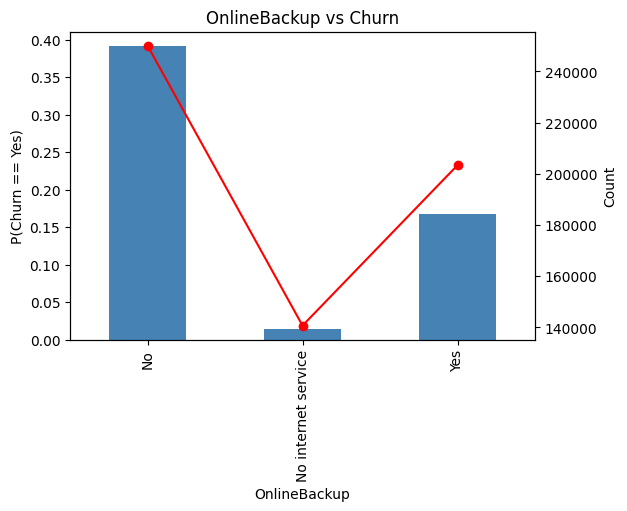

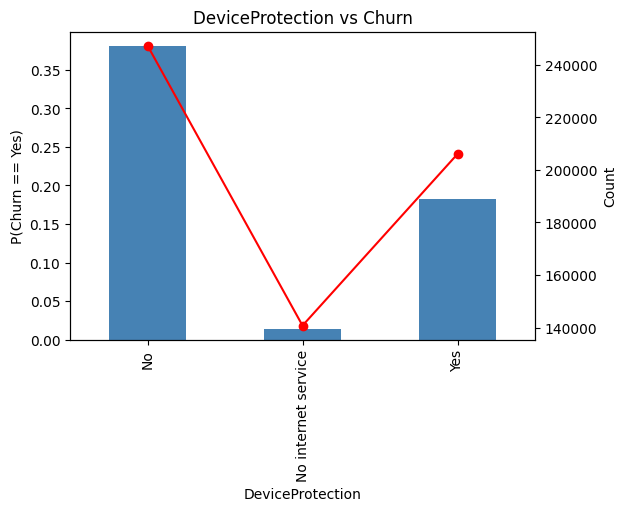

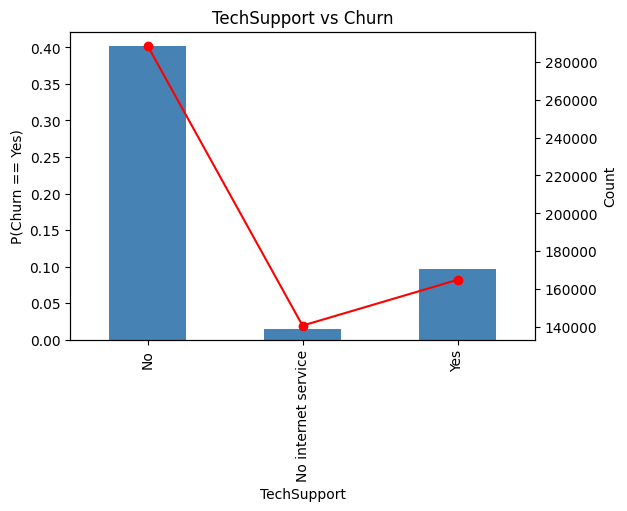

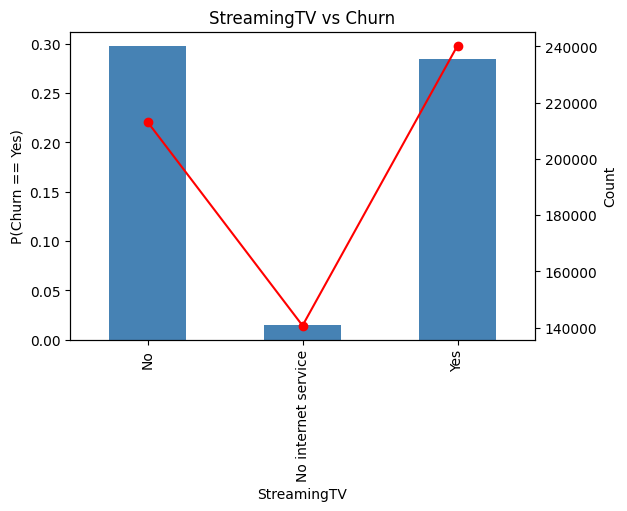

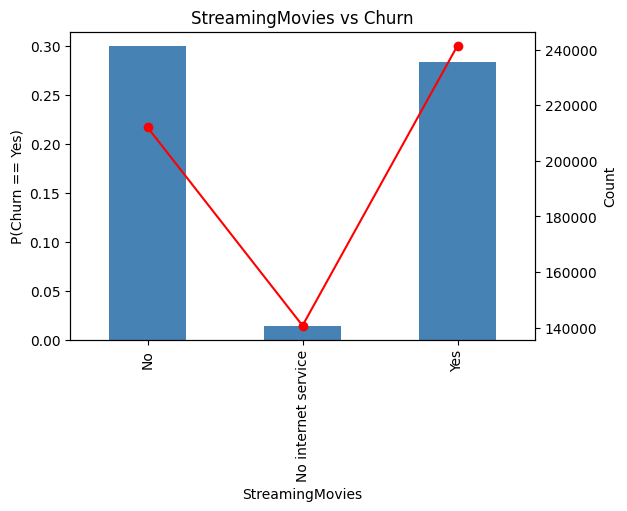

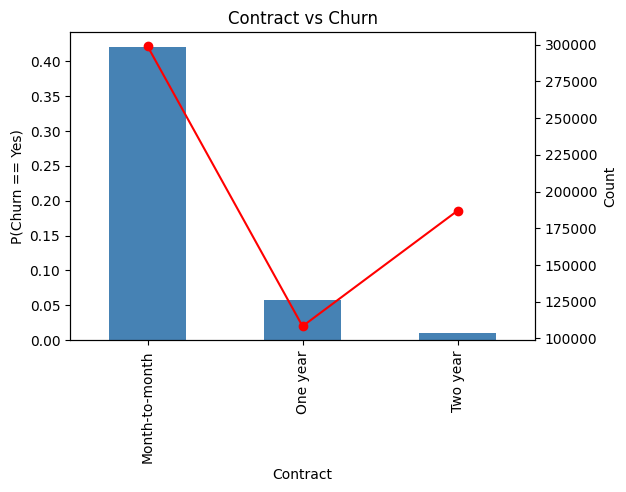

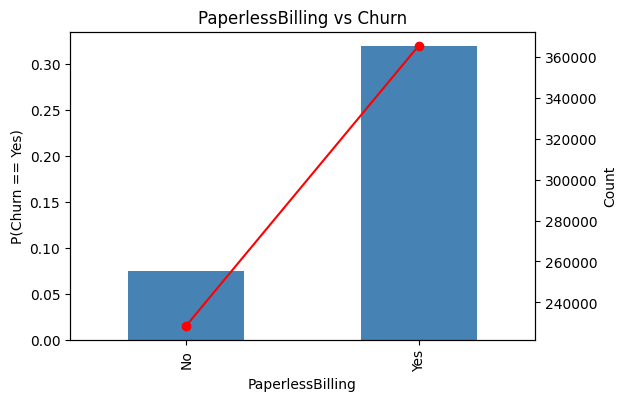

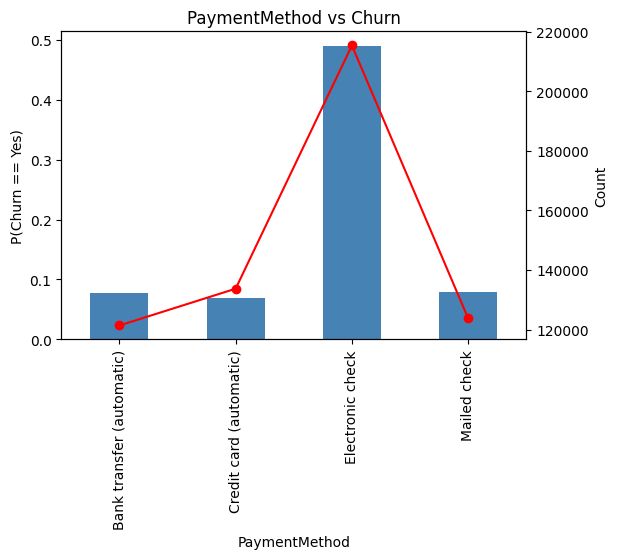

In [29]:
def plot_cat_target(df, feature):
    prob = df.groupby(feature)["target"].mean()
    count = df.groupby(feature)["target"].count()
    
    fig, ax1 = plt.subplots(figsize=(6,4))
    
    prob.plot(kind="bar", ax=ax1, color="steelblue")
    ax1.set_ylabel("P(Churn == Yes)")
    ax1.set_title(f"{feature} vs Churn")
    
    ax2 = ax1.twinx()
    count.plot(kind="line", ax=ax2, color="red", marker="o")
    ax2.set_ylabel("Count")
    
    plt.show()

for i in cat_cols:
    if i == 'Churn':
        continue
    plot_cat_target(df, i)


In [22]:
train.PaymentMethod.unique()

array(['Mailed check', 'Credit card (automatic)', 'Electronic check',
       'Bank transfer (automatic)'], dtype=object)

In [103]:
preprocess_data()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,1,0,1,1,29,1,1,2,2,1,2,2,1,1,1,1,1,60.10,1653.85,0
1,1,0,1,1,58,1,1,2,2,2,1,2,2,1,0,0,2,69.50,3778.20,0
2,1,0,1,1,58,1,2,1,1,2,1,1,2,2,2,1,3,100.40,5841.35,0
3,0,0,1,1,1,1,1,1,1,1,1,1,1,1,2,1,3,69.70,70.70,1
4,0,0,1,1,1,1,1,1,1,1,1,1,1,1,2,1,3,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,1,0,1,1,57,1,2,1,1,1,2,1,2,2,0,0,0,97.55,5460.70,0
594190,0,0,1,1,72,1,2,2,2,2,2,2,2,2,0,0,0,91.95,6782.15,0
594191,0,0,1,1,72,1,2,3,0,0,0,0,0,0,0,0,2,24.40,1871.90,0
594192,0,0,1,1,32,1,2,1,1,1,1,1,1,2,2,1,3,86.00,2847.20,0


In [102]:

preprocess_data().corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
gender,1.000000,0.000103,NaN,NaN,0.001504,NaN,-0.014036,0.009630,-0.007987,-0.007438,-0.009024,-0.009006,-0.009538,-0.009142,0.000159,-0.005776,-0.001363,-0.013647,-0.006192,-0.006808
SeniorCitizen,0.000103,1.000000,NaN,NaN,-0.084291,NaN,0.140325,-0.273773,0.060054,0.118794,0.126154,0.057761,0.182345,0.181574,0.198653,0.199061,0.202752,0.229079,0.042786,0.236362
Partner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,0.001504,-0.084291,NaN,NaN,1.000000,NaN,0.229202,0.141860,0.161531,0.168125,0.177976,0.177274,0.109560,0.110200,-0.753957,-0.113104,-0.306560,0.124043,0.769703,-0.418453
PhoneService,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,-0.014036,0.140325,NaN,NaN,0.229202,NaN,1.000000,-0.364621,0.152109,0.218903,0.239023,0.166762,0.291309,0.289145,-0.048217,0.216502,0.113917,0.533003,0.426951,0.109066
InternetService,0.009630,-0.273773,NaN,NaN,0.141860,NaN,-0.364621,1.000000,-0.579159,-0.659696,-0.674406,-0.588389,-0.755300,-0.754249,-0.433977,-0.534388,-0.422975,-0.902826,-0.370470,-0.408363
OnlineSecurity,-0.007987,0.060054,NaN,NaN,0.161531,NaN,0.152109,-0.579159,1.000000,0.747244,0.745017,0.783102,0.698795,0.699749,0.042933,0.290843,0.100511,0.667498,0.524226,0.039353
OnlineBackup,-0.007438,0.118794,NaN,NaN,0.168125,NaN,0.218903,-0.659696,0.747244,1.000000,0.757188,0.756234,0.742818,0.744088,0.089176,0.351762,0.161876,0.748134,0.570295,0.095632


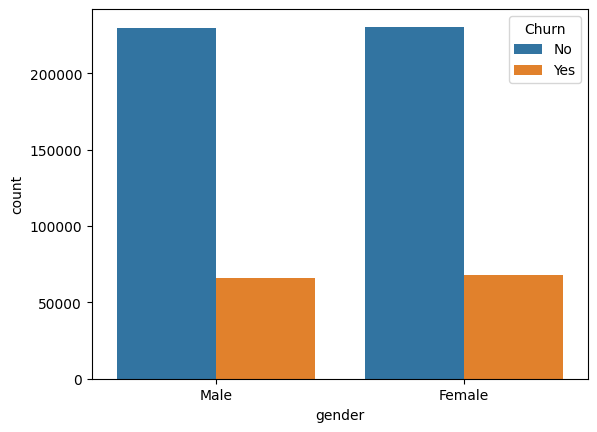

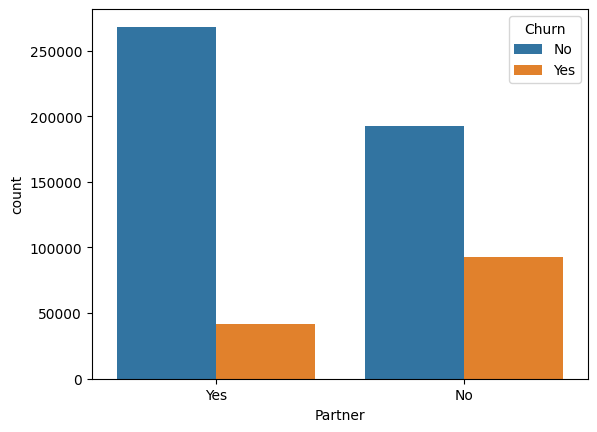

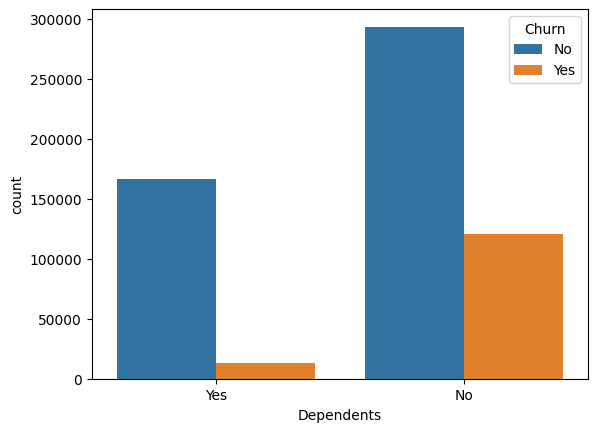

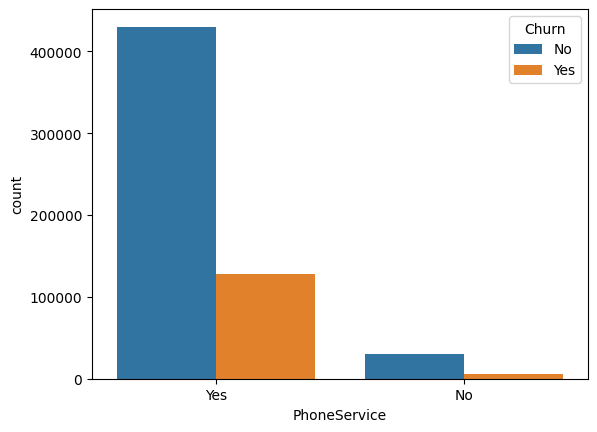

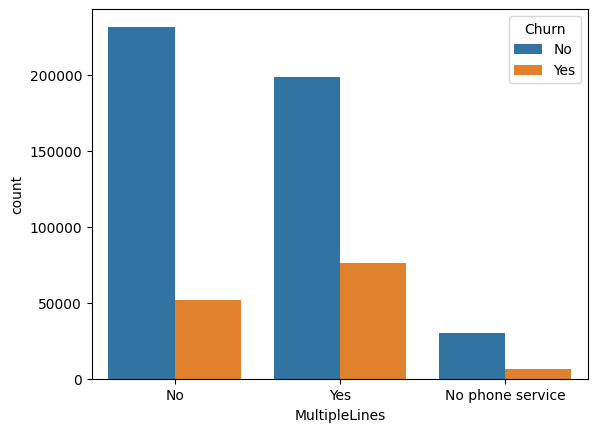

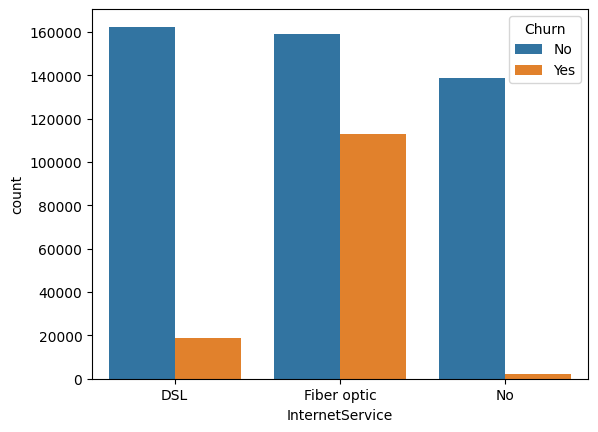

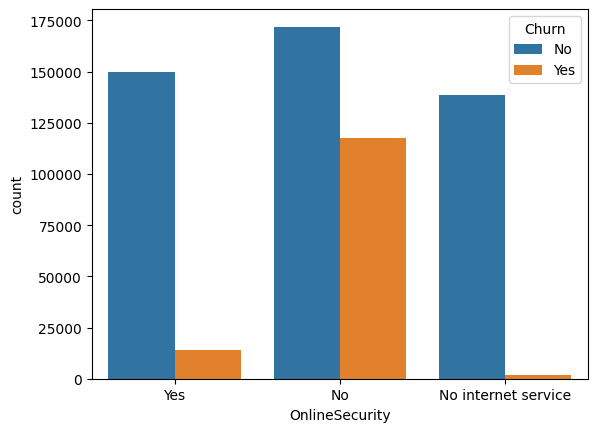

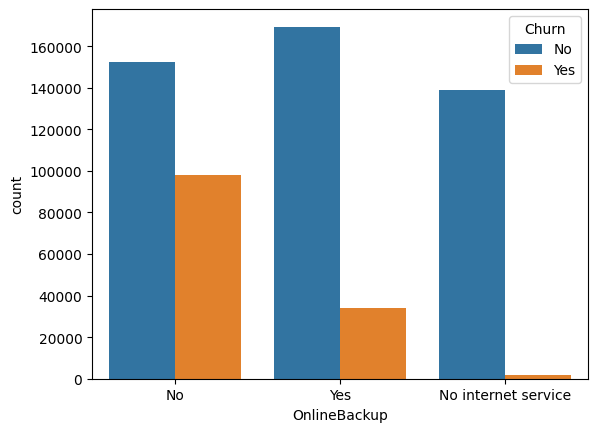

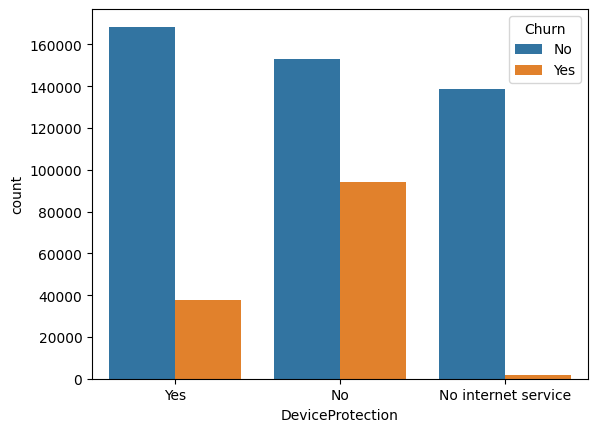

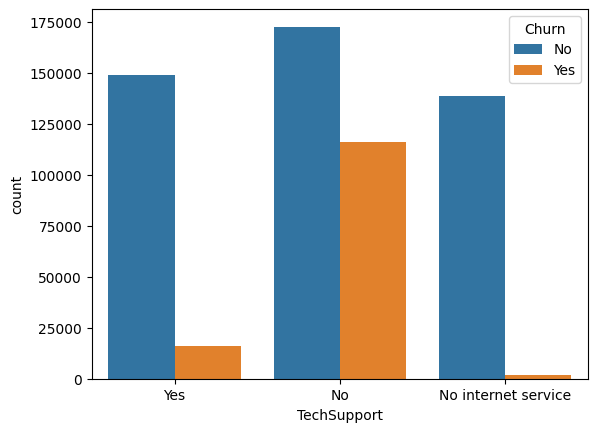

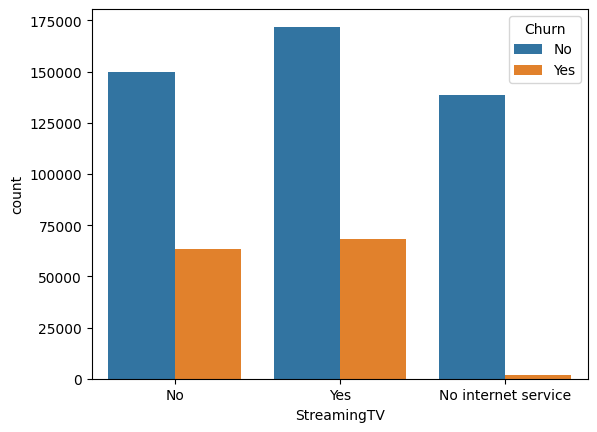

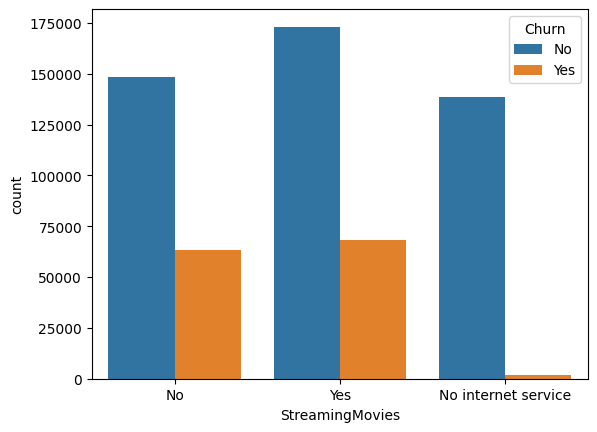

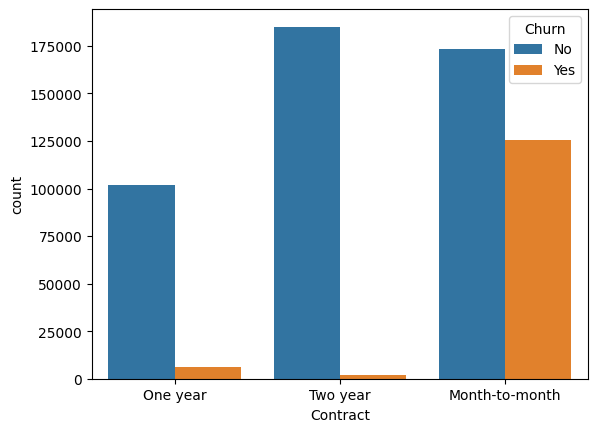

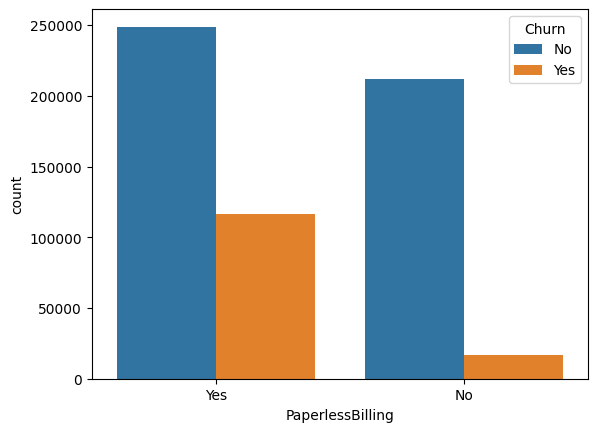

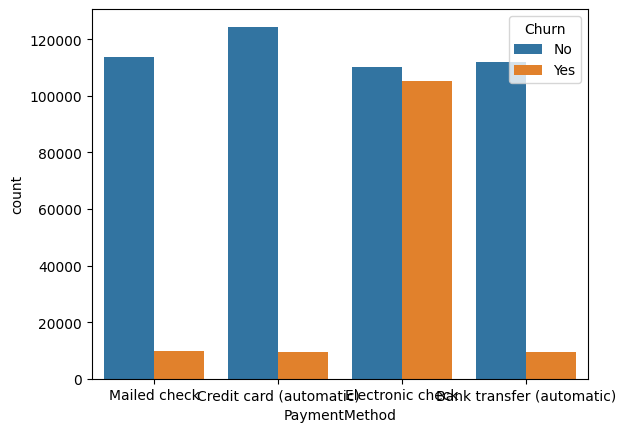

In [104]:
# Churn vs Gender
test_cats = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
]
for i in test_cats:
    sns.countplot(x=i, hue='Churn', data=train)
    plt.show()


In [105]:
train.describe(include=['object'])

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


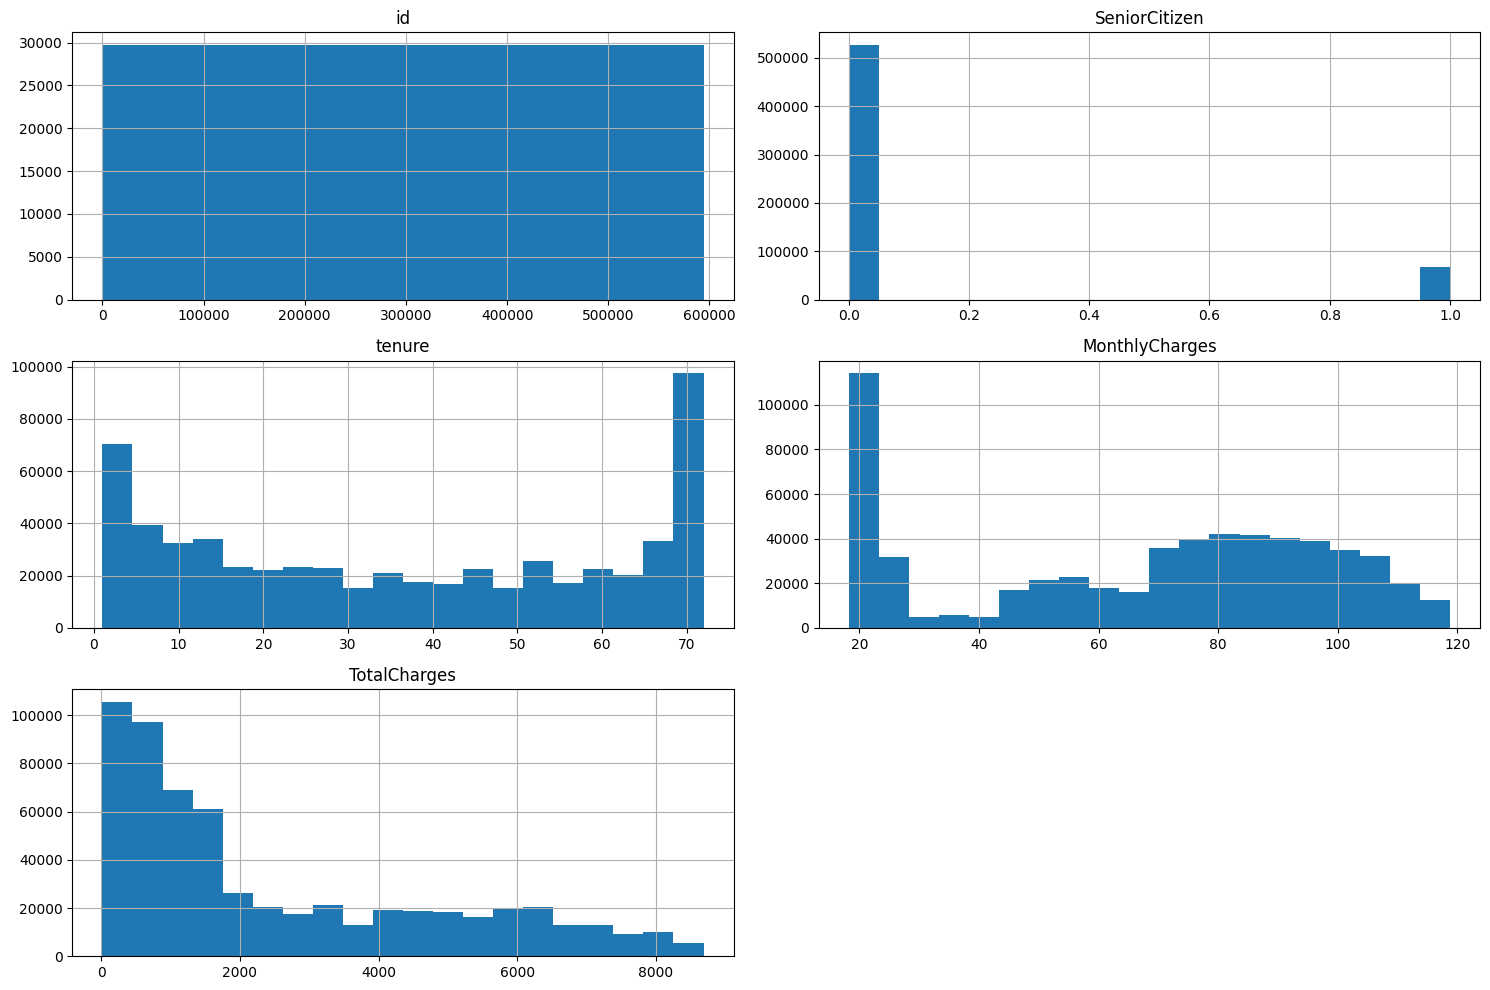

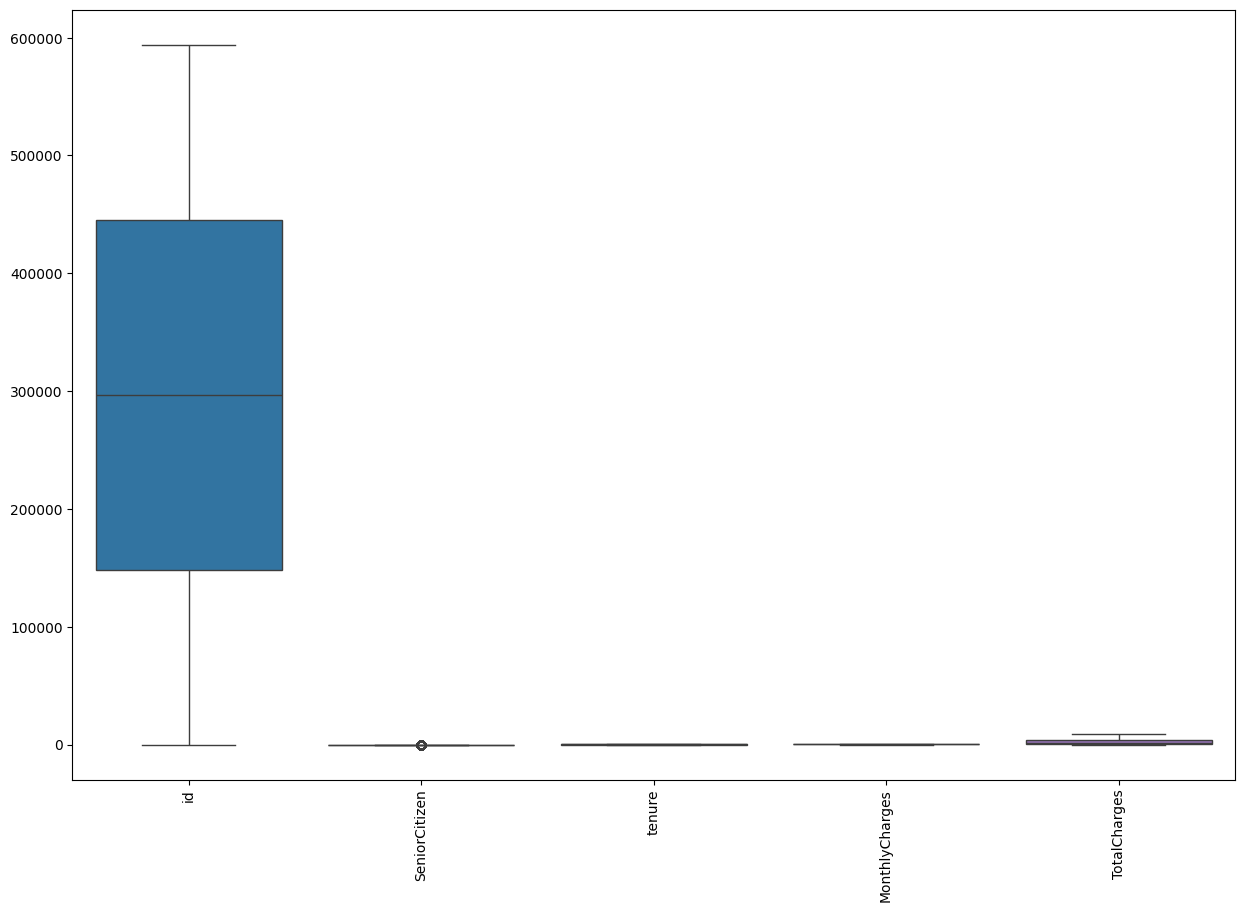

In [106]:
# Histograms for numerical columns
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
train[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Boxplots for outliers (for individual numerical columns)
plt.figure(figsize=(15, 10))
sns.boxplot(data=train[numerical_cols])
plt.xticks(rotation=90)
plt.show()

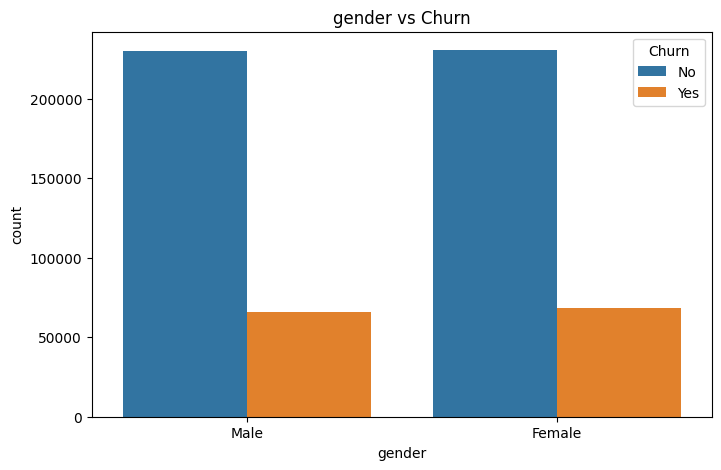

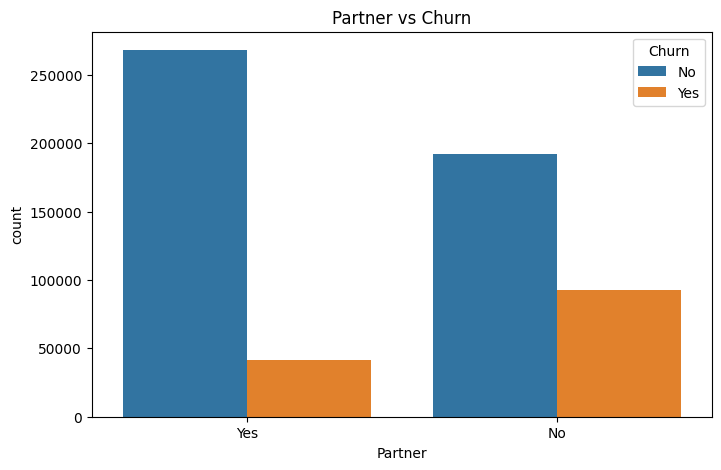

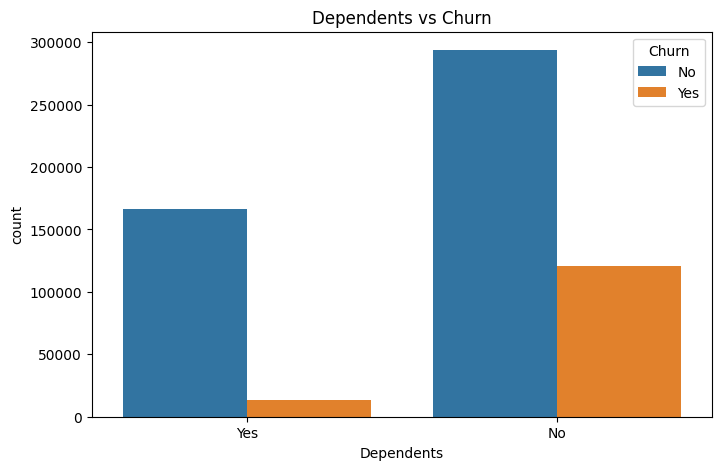

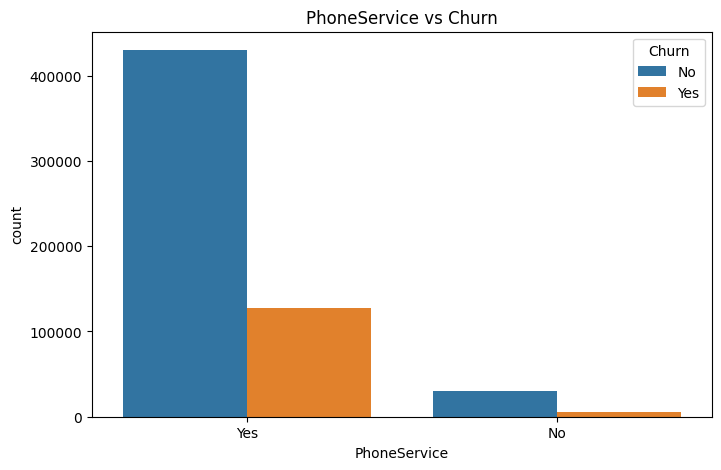

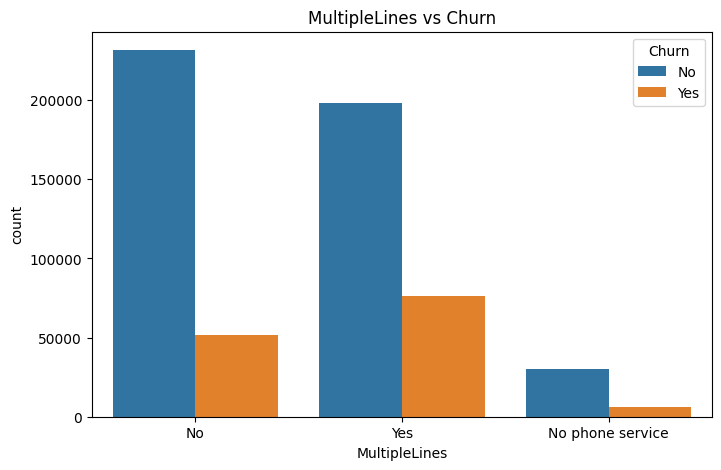

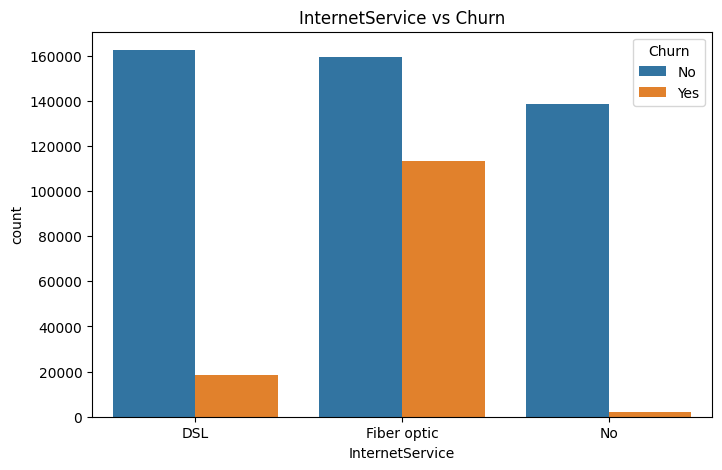

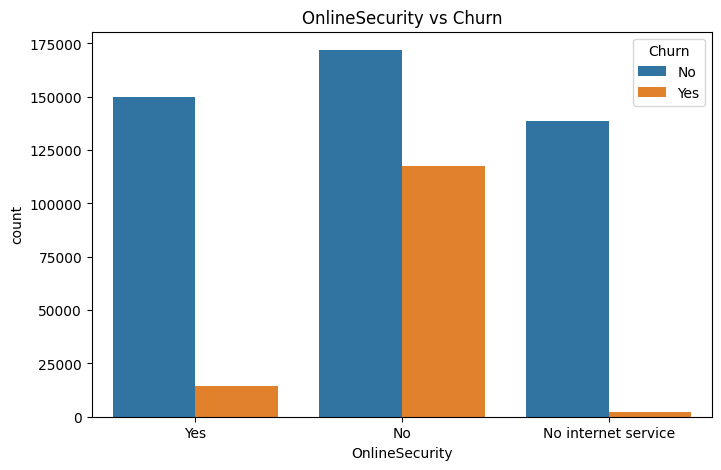

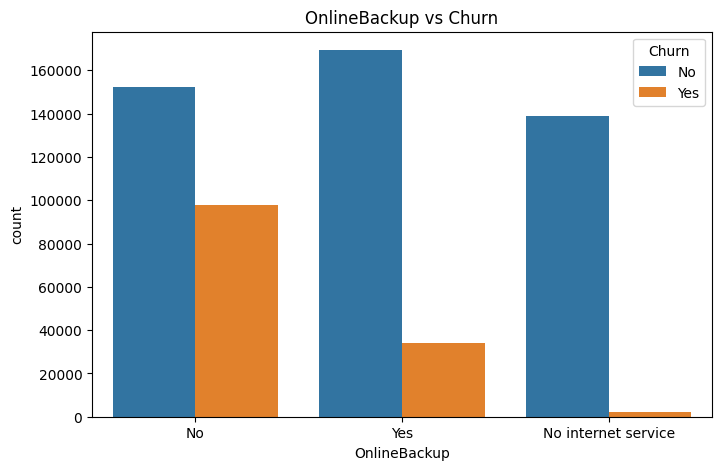

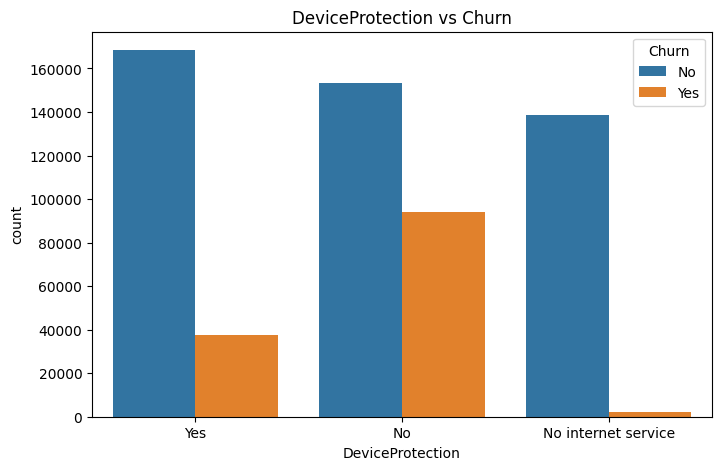

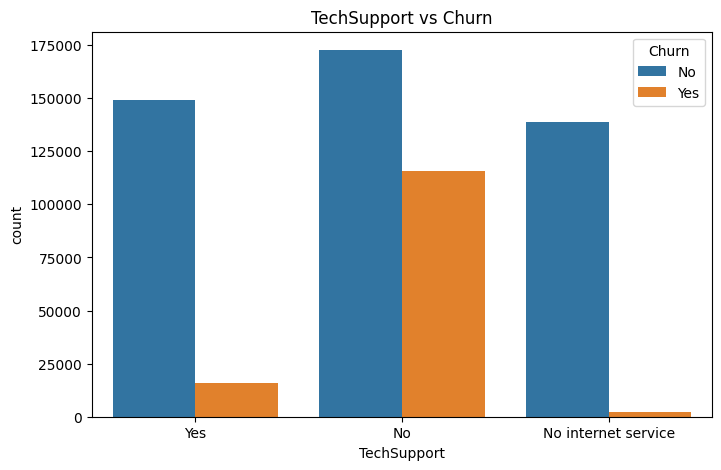

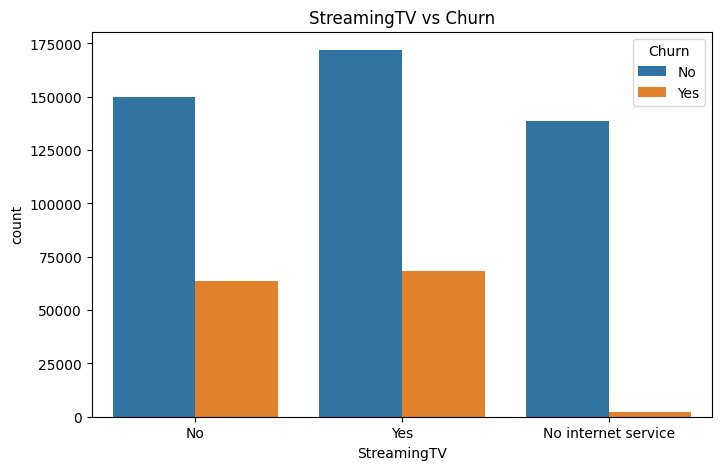

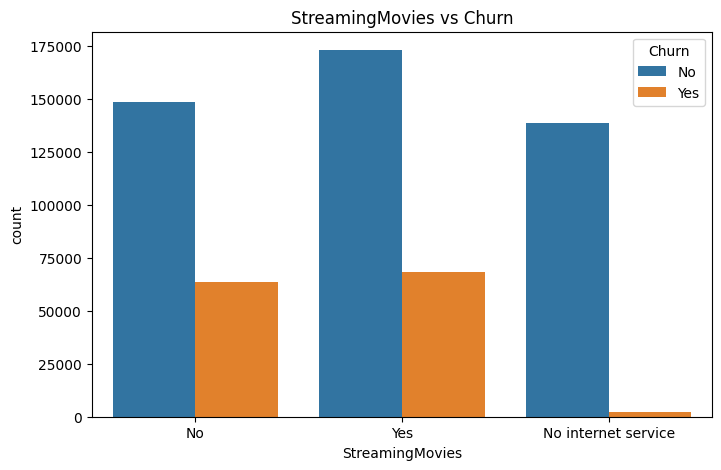

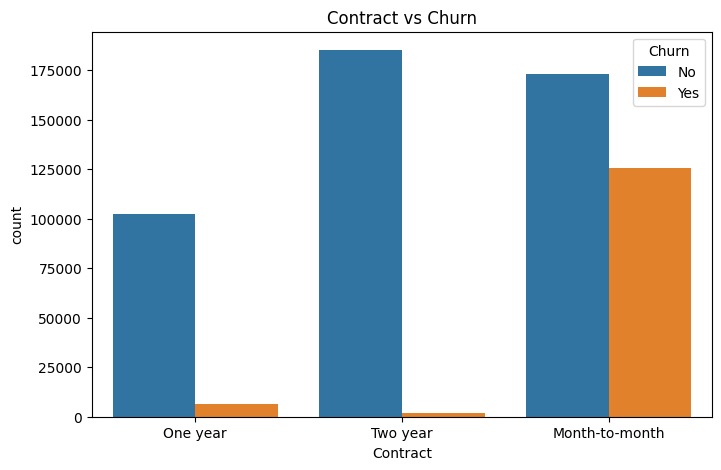

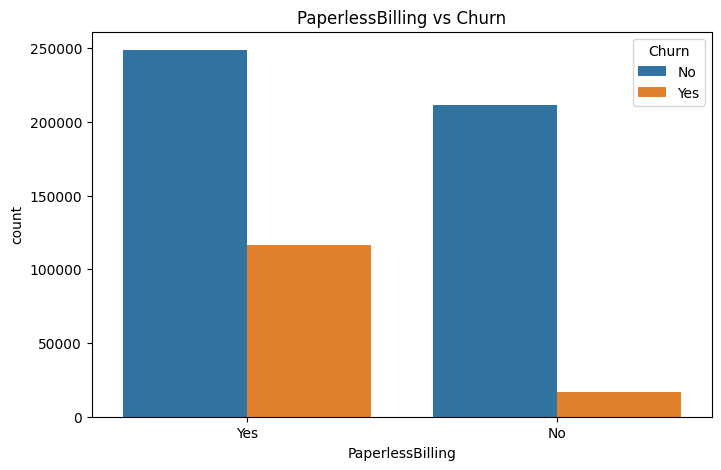

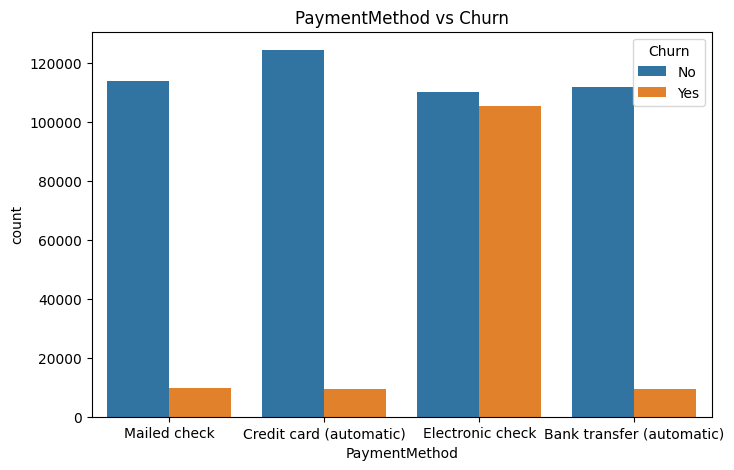

In [107]:
# Plot the distribution of categorical features
categorical_cols = train.select_dtypes(include=['object']).columns

# For each categorical variable, visualize its distribution
for col in categorical_cols:
    if col != 'Churn':  # Skip the target column
        plt.figure(figsize=(8, 5))
        sns.countplot(x=col, hue='Churn', data=train)
        plt.title(f'{col} vs Churn')
        plt.show()

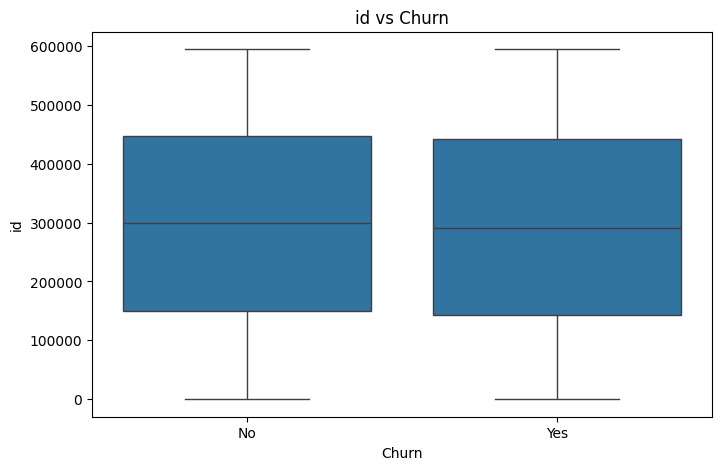

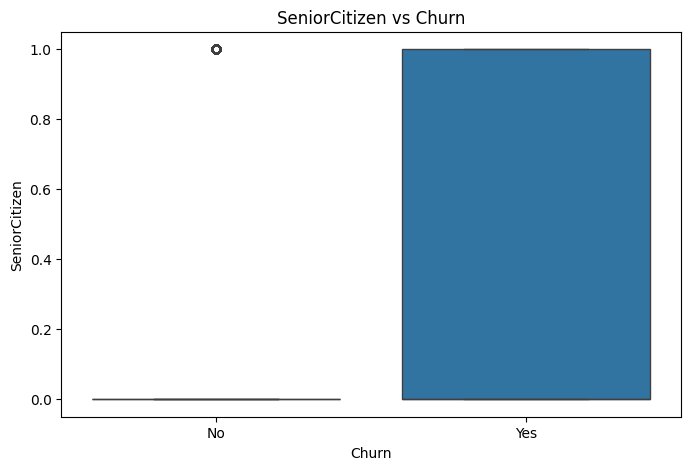

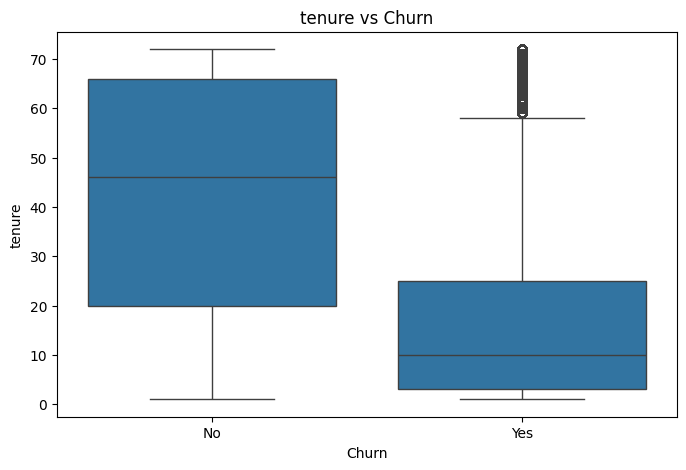

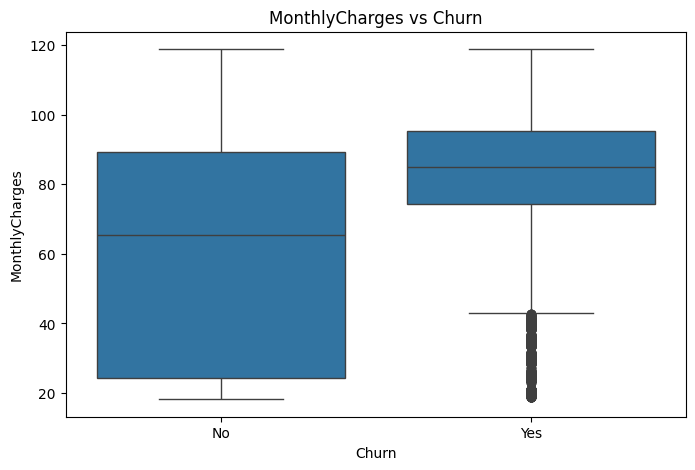

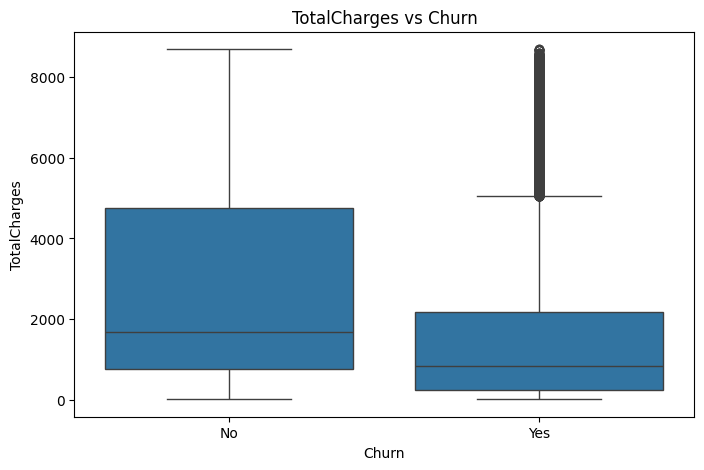

In [108]:
# Boxplots to visualize numerical features vs Churn
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y=col, data=train)
    plt.title(f'{col} vs Churn')
    plt.show()

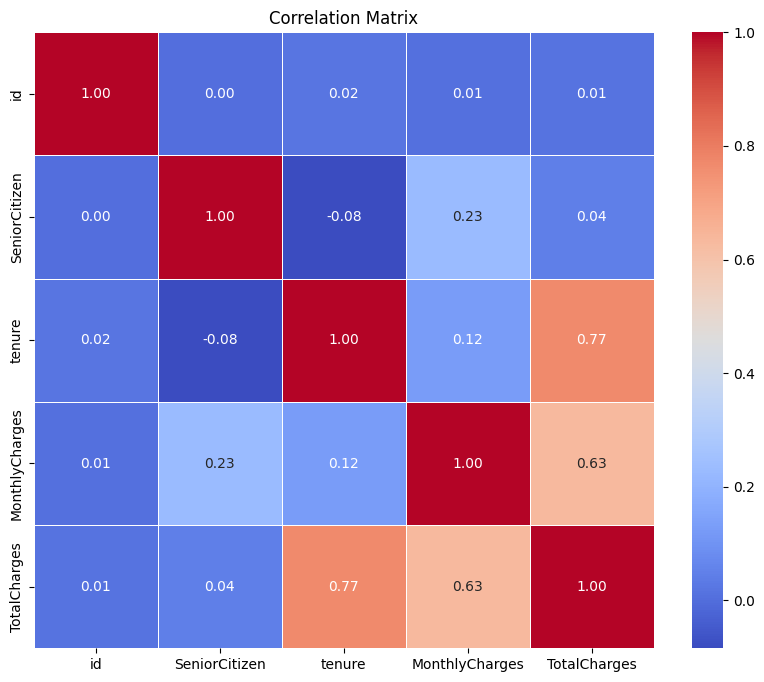

In [111]:
# Correlation matrix to understand relationships between numerical features
corr = train[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [112]:
from scipy.stats import chi2_contingency

# Chi-Square test for categorical columns
for col in categorical_cols:
    if col != 'Churn':
        contingency_table = pd.crosstab(train[col], train['Churn'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f'Chi-Square Test for {col}: p-value = {p}')

Chi-Square Test for gender: p-value = 1.561933705084728e-07
Chi-Square Test for Partner: p-value = 0.0
Chi-Square Test for Dependents: p-value = 0.0
Chi-Square Test for PhoneService: p-value = 8.013131829774979e-159
Chi-Square Test for MultipleLines: p-value = 0.0
Chi-Square Test for InternetService: p-value = 0.0
Chi-Square Test for OnlineSecurity: p-value = 0.0
Chi-Square Test for OnlineBackup: p-value = 0.0
Chi-Square Test for DeviceProtection: p-value = 0.0
Chi-Square Test for TechSupport: p-value = 0.0
Chi-Square Test for StreamingTV: p-value = 0.0
Chi-Square Test for StreamingMovies: p-value = 0.0
Chi-Square Test for Contract: p-value = 0.0
Chi-Square Test for PaperlessBilling: p-value = 0.0
Chi-Square Test for PaymentMethod: p-value = 0.0


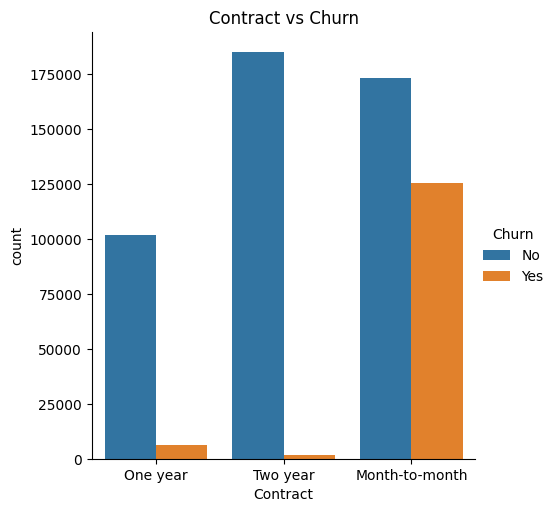

In [113]:
# Stacked barplot to see the relationship between two categorical variables
sns.catplot(x="Contract", hue="Churn", kind="count", data=train)
plt.title('Contract vs Churn')
plt.show()

In [101]:
df["OtherCharges"]=df.TotalCharges - df.MonthlyCharges
df[["OtherCharges", "MonthlyCharges", "TotalCharges", "target"]].corr()

,OtherCharges,MonthlyCharges,TotalCharges,target
OtherCharges,1.000000,0.626248,0.999947,-0.223830
MonthlyCharges,0.626248,1.000000,0.634237,0.272997
TotalCharges,0.999947,0.634237,1.000000,-0.218365
target,-0.223830,0.272997,-0.218365,1.000000


In [19]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,0
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,0
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,0
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,0


In [119]:
def preprocess_data(df: pd.DataFrame = None):
    if df is None:
        df = train.copy()
        df['target'] = (df['Churn'] == 'Yes').astype(int)
        df = df.drop(columns='Churn')
    df = df.drop(columns=['id'])

    bins = [0, 6, 12, 24, 48, 64, 75]
    labels = [3, 6, 9, 12, 16, 24]
    df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

    partner_map = {'Yes': 1, 'No': 1}
    df["Partner"] = df["Partner"].map(partner_map)

    dependents_map = {'Yes': 1, 'No': 1}
    df["Dependents"] = df["Dependents"].map(dependents_map)

    phoneservice_map = {'Yes': 1, 'No': 1}
    df["PhoneService"] = df["PhoneService"].map(phoneservice_map)

    internet_map = {'Fiber optic': 1, 'DSL': 2, 'No':3}
    df["InternetService"] = df["InternetService"].map(internet_map)    
    
    multiple_lines = {'Yes': 2, 'No': 1, 'No phone service': 0}
    df["MultipleLines"] = df["MultipleLines"].map(multiple_lines)

    online_security = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["OnlineSecurity"] = df["OnlineSecurity"].map(online_security)    
    
    device_protection = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["DeviceProtection"] = df["DeviceProtection"].map(device_protection)    
    
    TechSupport = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["TechSupport"] = df["TechSupport"].map(TechSupport)

    StreamingTV = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["StreamingTV"] = df["StreamingTV"].map(StreamingTV)

    PaperlessBilling = {'Yes': 1, 'No': 0}
    df["PaperlessBilling"] = df["PaperlessBilling"].map(PaperlessBilling)
    
    Contract = {'Month-to-month': 2, 'One year': 1, 'Two year': 0}
    df["Contract"] = df["Contract"].map(Contract)

    StreamingMovies = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["StreamingMovies"] = df["StreamingMovies"].map(StreamingMovies)

    PaymentMethod = {'Electronic check': 3, 'Credit card (automatic)': 2, "Mailed check": 1, "Bank transfer (automatic)": 0}
    df["PaymentMethod"] = df["PaymentMethod"].map(PaymentMethod)

    OnlineBackup = {'Yes': 2, 'No': 1, "No internet service": 0}
    df["OnlineBackup"] = df["OnlineBackup"].map(OnlineBackup)

    gender = {'Male': 1, 'Female': 0}
    df["gender"] = df["gender"].map(gender)

    return df

preprocess_data()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target,tenure_group
0,1,0,1,1,29,1,1,2,2,1,...,2,1,1,1,1,1,60.10,1653.85,0,12
1,1,0,1,1,58,1,1,2,2,2,...,2,2,1,0,0,2,69.50,3778.20,0,16
2,1,0,1,1,58,1,2,1,1,2,...,1,2,2,2,1,3,100.40,5841.35,0,16
3,0,0,1,1,1,1,1,1,1,1,...,1,1,1,2,1,3,69.70,70.70,1,3
4,0,0,1,1,1,1,1,1,1,1,...,1,1,1,2,1,3,70.45,70.45,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,1,0,1,1,57,1,2,1,1,1,...,1,2,2,0,0,0,97.55,5460.70,0,16
594190,0,0,1,1,72,1,2,2,2,2,...,2,2,2,0,0,0,91.95,6782.15,0,24
594191,0,0,1,1,72,1,2,3,0,0,...,0,0,0,0,0,2,24.40,1871.90,0,24
594192,0,0,1,1,32,1,2,1,1,1,...,1,1,2,2,1,3,86.00,2847.20,0,12


In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import numpy as np

# ----------------------------
# Feature / target
# ----------------------------
train_raw = preprocess_data()

X = train_raw.drop(columns=["target"])
y = train_raw["target"]

# num_cols.extend(newly_adds)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

coefs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Scaling (fit ONLY on train)
    # ----------------------------
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # ----------------------------
    # Model
    # ----------------------------
    log_reg = LogisticRegression(
        max_iter=10000,
        solver="lbfgs"
    )

    log_reg.fit(X_train_scaled, y_train)

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = log_reg.predict(X_val_scaled)
    y_proba = log_reg.predict_proba(X_val_scaled)[:, 1]

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    coefs.append(log_reg.coef_[0])

    print(f"Fold {fold} done")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average coefficients
# ----------------------------
coef_mean = pd.Series(
    np.mean(coefs, axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nAverage coefficients across folds:")
print(coef_mean)

print("\nAverage odds ratios:")
print(np.exp(coef_mean))


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

CV Results (mean ± std):
ACCURACY  : 0.8530 ± 0.0010
ROC_AUC   : 0.9064 ± 0.0010
PRECISION : 0.6820 ± 0.0029
RECALL    : 0.6507 ± 0.0034
F1        : 0.6659 ± 0.0021

Average coefficients across folds:
TotalCharges        0.820712
Contract            0.680154
StreamingTV         0.454513
StreamingMovies     0.432515
PaymentMethod       0.325329
PaperlessBilling    0.214971
MultipleLines       0.209631
SeniorCitizen       0.159878
DeviceProtection    0.011659
Dependents          0.000000
Partner             0.000000
PhoneService        0.000000
gender             -0.008531
OnlineBackup       -0.016831
TechSupport        -0.133182
OnlineSecurity     -0.243096
MonthlyCharges     -0.693755
InternetService    -1.146952
tenure             -1.816397
dtype: float64

Average odds ratios:
TotalCharges        2.272118
Contract            1.974182
StreamingTV         1.575406
StreamingMovies     1.541128
PaymentMethod       1.384487
Paper

Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64

## LGBM


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     92076
           1       0.71      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

Fold 1 done with ROC-AUC: 0.9155985961079863
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.65      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    11883

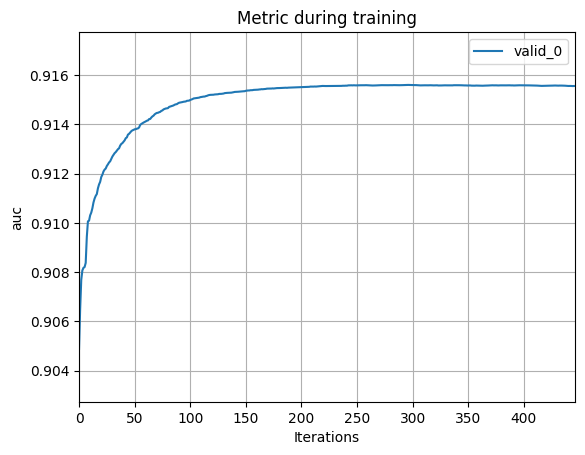

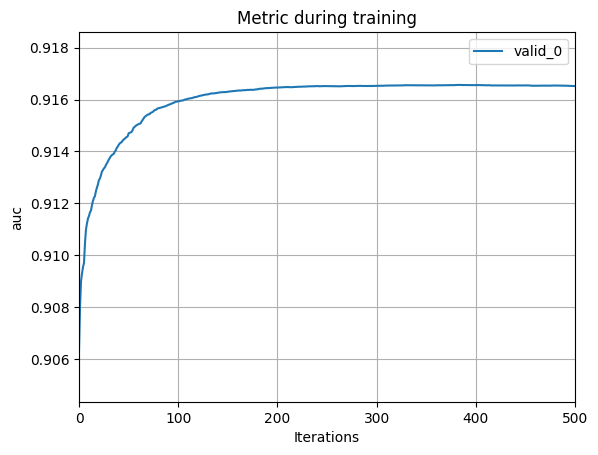

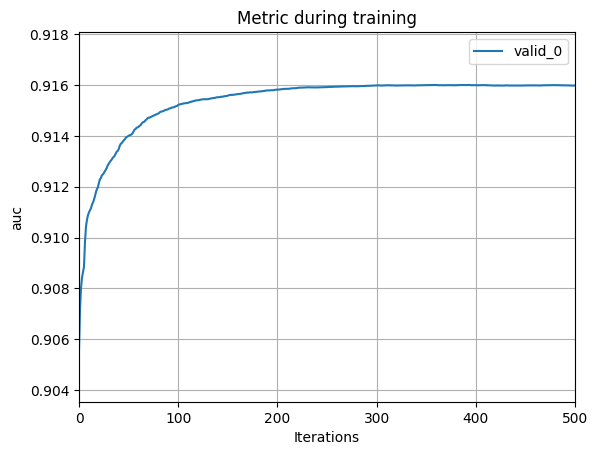

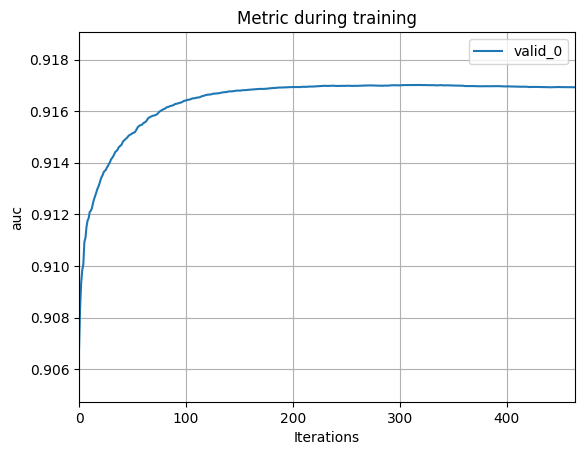

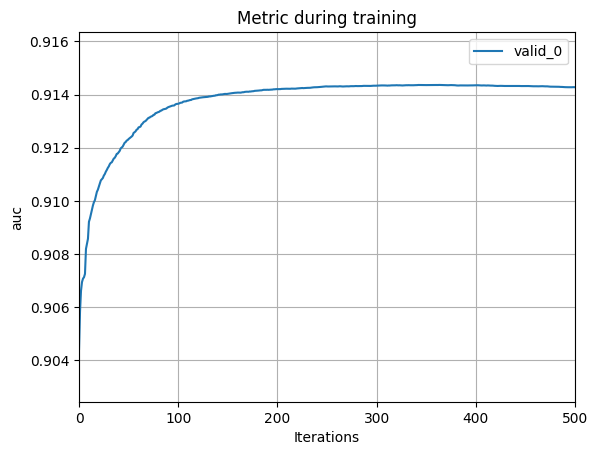

In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

# ----------------------------
# Feature / target
# ----------------------------
# X = df.drop(columns=["target"])
# y = df["target"]

# X_test = test.drop(columns='id')

train_raw = preprocess_data()
X = train_raw.drop(columns=["target"])
y = train_raw["target"]
test_raw = preprocess_data(test)

X_test = test_raw
num_cols = X.columns

# num_cols = [
#     'Thallium', 'Sex', 'Slope of ST', 'Age',
#     'Number of vessels fluro', 'Exercise angina',
#     'Max HR', 'Chest pain type', 'EKG results',
#     'Cholesterol', 'FBS over 120', 'BP',
#     'ST depression'
# ]
# cat_cols = [
#     # 'Sex',
#     'Chest pain type',
#     # 'Exercise angina',
#     # 'Number of vessels fluro',
#     # 'Thallium'
# ]
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    '''Preprocess of features.'''
    # df['Number of vessels fluro'] = (df['Number of vessels fluro'] - 3) * -1
    new_cols = []
    # bins = [0, 35, 55, 70, 80]
    # labels = [1, 2, 3, 4]
    # df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

    # X['Thallium_x2'] = X['Thallium'] / X['Slope of ST']
    # X_test['Thallium_x2'] = X_test['Thallium'] / X_test['Slope of ST']
    
    # bins = [0, 1, 2, 3, 4.5, 5.5]
    # labels = [1, 2, 3, 4, 5]
    # df['dep x age'] = pd.cut(df['ST depression'], bins=bins, labels=labels, right=False).astype('float')
    # df['dep x age'] = df['Age'] / df['dep x age']
    # new_cols.append('dep x age')
    # df[cat_cols] = df[cat_cols].astype('category')
    # data = pd.get_dummies(df[cat_cols], drop_first=True)
    # print(data.columns)
    # df = pd.concat([df.drop(columns=cat_cols), data], axis=1)
    # print(df.columns)
    # new_cols = ['Age Group']
    # df['Thallium_x_age'] = df['Thallium'] * (df['Age']**0.5)
    # df["num_fluro"] = (df['Number of vessels fluro'] > 0).astype(int)
    # df['st_slope'] = (df['Slope of ST'] > 1).astype(int)
    # df = df.drop(columns= [ 'Slope of ST'])
    # df["st_x_age"] = (df['Age'] * np.log1p(df['ST depression']))
    # new_cols.append('st_x_age')
    # for i in new_cols:
    #     if i not in num_cols:
    #         num_cols.append(i)
    # num_cols.append('Thallium_x2')
    return df


X = preprocess(X[num_cols].copy())
X_test = preprocess(X_test[num_cols].copy())

print(X.columns)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

importances = []

X_res = np.zeros(len(X_test))
X_res_oof = np.zeros(len(X))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Model
    # ----------------------------
    xgb = LGBMClassifier(
        objective="binary",
        metric="auc",

        n_estimators=500,
        learning_rate=0.1,

        max_depth=-1,          # let num_leaves control complexity
        num_leaves=48,

        subsample=0.9,
        colsample_bytree=0.9,

        min_child_samples=100,
        reg_alpha=5,
        reg_lambda=5,

        random_state=42,
        n_jobs=-1,
        verbose=-1,
        early_stopping_rounds = 150
    )


    xgb.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        # verbose=False
    )

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = xgb.predict(X_val, num_iteration=xgb.best_iteration_)
    y_proba = xgb.predict_proba(X_val, num_iteration=xgb.best_iteration_)[:, 1]
    X_res += xgb.predict_proba(X_test, num_iteration=xgb.best_iteration_)[:, 1]/5
    X_res_oof += xgb.predict_proba(X, num_iteration=xgb.best_iteration_)[:, 1]/5

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    importances.append(xgb.feature_importances_)
    lgb.plot_metric(booster=xgb)
    print(classification_report(y_val, y_pred))
    print(f"Fold {fold} done", f"with ROC-AUC: {metrics['roc_auc'][-1]}")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average feature importance
# ----------------------------
importance_mean = pd.Series(
    np.mean(importances, axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nAverage feature importances:")
print(importance_mean)

sub_df = pd.DataFrame({'id': test['id'], 'Churn': X_res})


In [53]:
os.listdir()

['data', 'eda.ipynb']

In [62]:
os.listdir('results')

['sub01.csv', 'sub02.csv']

In [91]:
def write_results():
    files = os.listdir('results')
    counts = []
    for i in files:
        name = i.split('.')[0]
        no = name.split('b')[-1]
        no = int(no) 
        counts.append(no)
    max_no = max(counts) + 1
    print(f"Saving File no{max_no:02d}")
    sub_df = pd.DataFrame({'id': test['id'], 'Churn': X_res})
    sub_df.to_csv(f"results/sub{max_no:2d}.csv", index=False)

In [89]:
write_results()

04


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,1,1,29,1,1,2,2,1,2,2,1,1,1,1,1,60.10,1653.85
1,1,0,1,1,58,1,1,2,2,2,1,2,2,1,0,0,2,69.50,3778.20
2,1,0,1,1,58,1,2,1,1,2,1,1,2,2,2,1,3,100.40,5841.35
4,0,0,1,1,1,1,1,1,1,1,1,1,1,1,2,1,3,70.45,70.45
8,0,1,1,1,1,1,2,1,1,1,2,1,1,1,2,1,3,79.55,79.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,1,0,1,1,57,1,2,1,1,1,2,1,2,2,0,0,0,97.55,5460.70
594190,0,0,1,1,72,1,2,2,2,2,2,2,2,2,0,0,0,91.95,6782.15
594191,0,0,1,1,72,1,2,3,0,0,0,0,0,0,0,0,2,24.40,1871.90
594192,0,0,1,1,32,1,2,1,1,1,1,1,1,2,2,1,3,86.00,2847.20


In [93]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'tenure_group'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     92076
           1       0.56      0.87      0.69     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.82      0.83    118839

Fold 1 done with ROC-AUC: 0.9154200338381727
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     92076
           1       0.56      0.88      0.68     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.84   

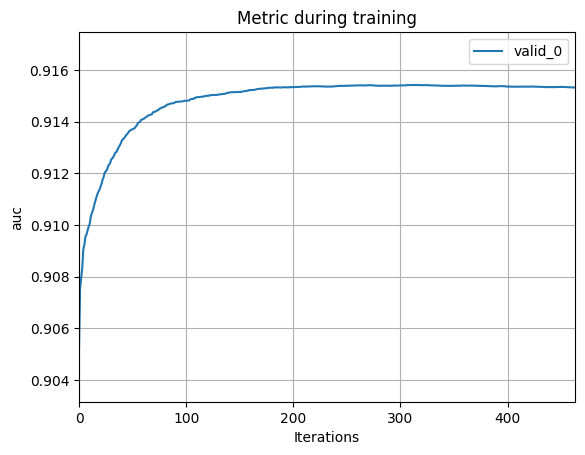

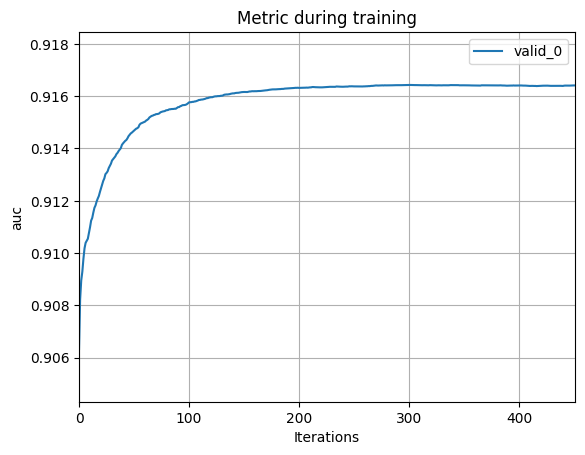

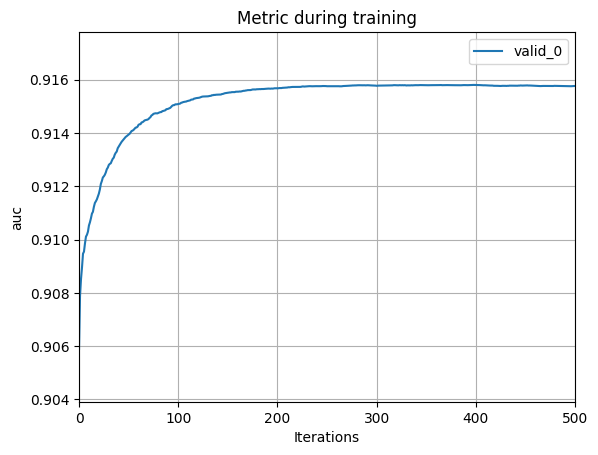

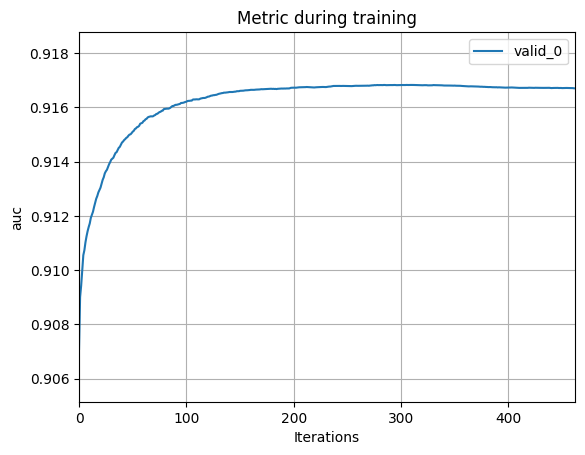

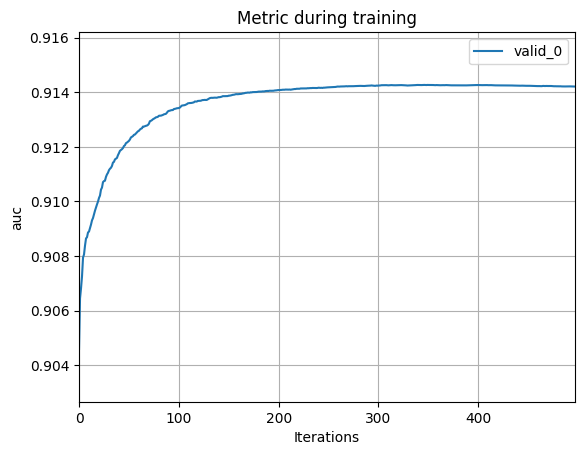

In [120]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd


train_raw = preprocess_data()
X = train_raw.drop(columns=["target"])
y = train_raw["target"]
test_raw = preprocess_data(test)

X_test = test_raw
num_cols = X.columns

category_cols = [
    # 'gender',
    # 'Partner',
    # 'Dependents',
    # 'PhoneService',
    # 'MultipleLines',
    # 'InternetService',
    # 'OnlineSecurity',
    # 'OnlineBackup',
    # 'DeviceProtection',
    # 'TechSupport',
    # 'StreamingTV',
    # 'StreamingMovies',
    # 'Contract',
    # 'PaperlessBilling',
    # 'PaymentMethod',
]

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    '''Preprocess of features.'''
    # df['Number of vessels fluro'] = (df['Number of vessels fluro'] - 3) * -1
    for i in category_cols:
        df[i] = df[i].astype('category')
    new_cols = []
    return df


X = preprocess(X[num_cols].copy())
X_test = preprocess(X_test[num_cols].copy())

print(X.columns)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

importances = []

X_res = np.zeros(len(X_test))
X_res_oof = np.zeros(len(X))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Model
    # ----------------------------
    lgb_model = LGBMClassifier(
        objective="binary",
        metric="auc",

        n_estimators=500,
        learning_rate=0.1,

        max_depth=-1,          # let num_leaves control complexity
        num_leaves=48,

        subsample=0.9,
        colsample_bytree=0.9,

        min_child_samples=100,
        reg_alpha=5,
        reg_lambda=5,

        is_unbalance =True,

        random_state=42,
        n_jobs=-1,
        verbose=-1,
        early_stopping_rounds = 150
    )


    lgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        categorical_feature = category_cols,
        # verbose=False
    )

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration_)
    y_proba = lgb_model.predict_proba(X_val, num_iteration=lgb_model.best_iteration_)[:, 1]
    X_res += lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]/5
    X_res_oof += lgb_model.predict_proba(X, num_iteration=lgb_model.best_iteration_)[:, 1]/5

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    importances.append(lgb_model.feature_importances_)
    lgb.plot_metric(booster=lgb_model)
    print(classification_report(y_val, y_pred))
    print(f"Fold {fold} done", f"with ROC-AUC: {metrics['roc_auc'][-1]}")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average feature importance
# ----------------------------
importance_mean = pd.Series(
    np.mean(importances, axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nAverage feature importances:")
print(importance_mean)

sub_df = pd.DataFrame({'id': test['id'], 'Churn': X_res})


<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

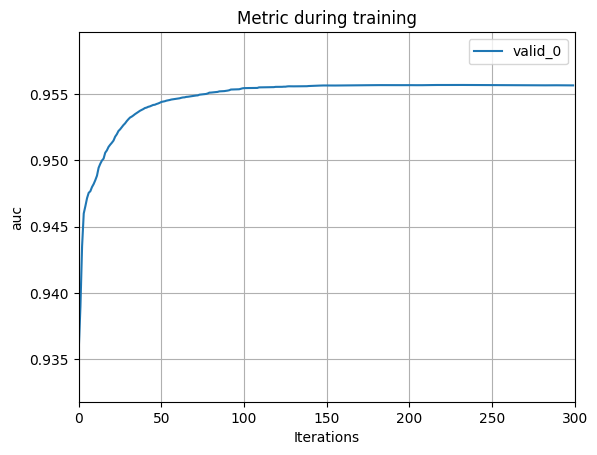

In [52]:
lgb.plot_metric(booster=xgb)

In [67]:
write_results()

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

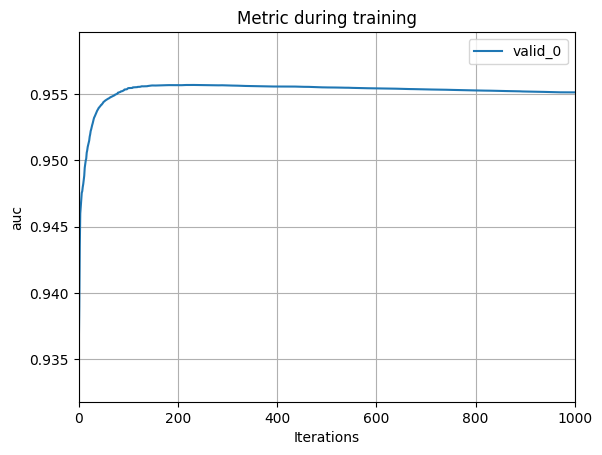

In [50]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

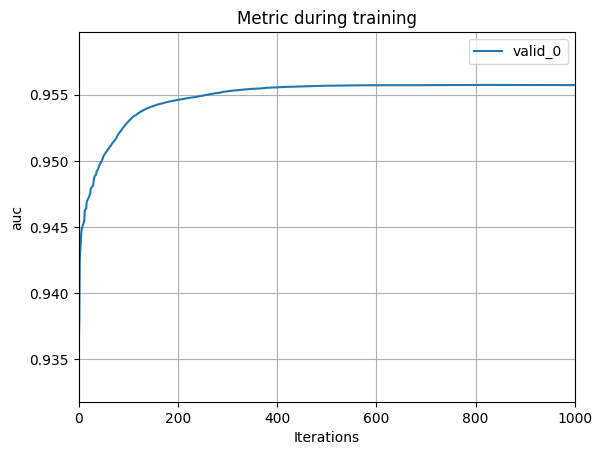

In [48]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

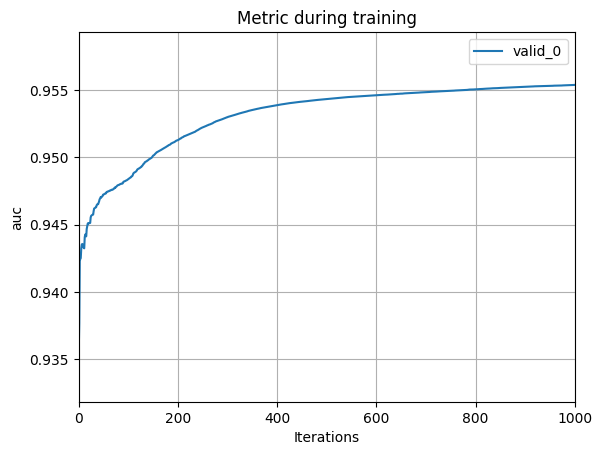

In [46]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

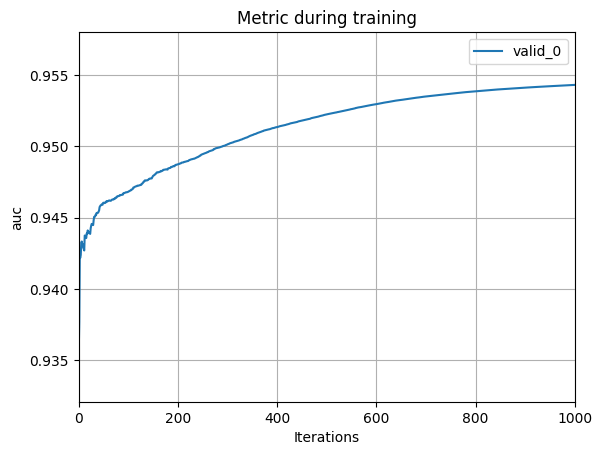

In [44]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

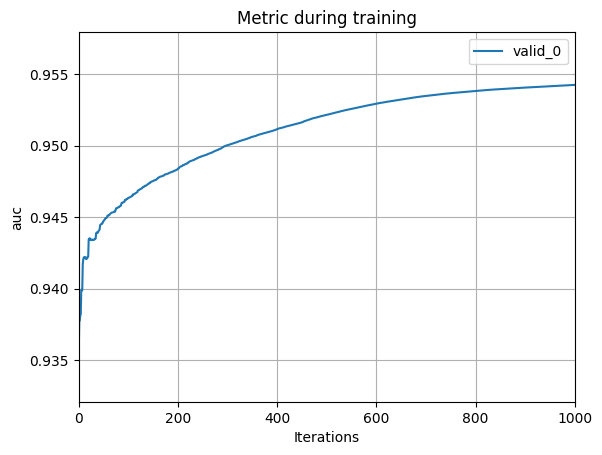

In [42]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

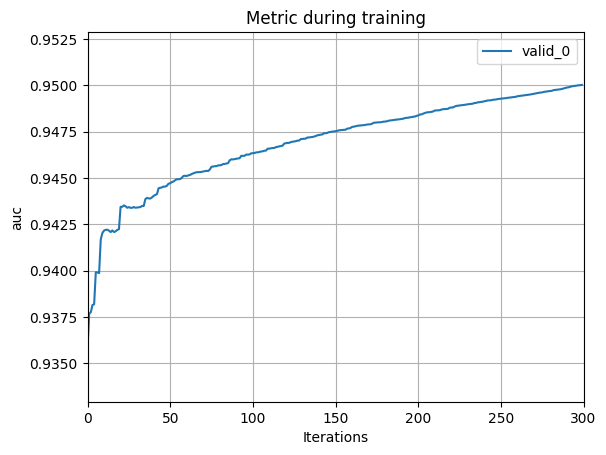

In [40]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

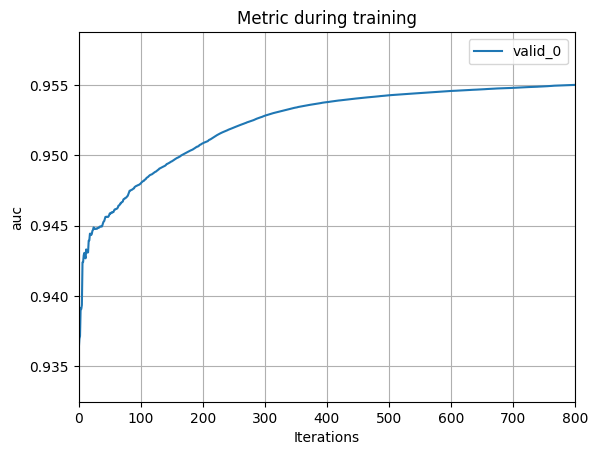

In [30]:
lgb.plot_metric(booster=xgb)

In [32]:
booster = xgb.booster_
tree_info = booster.dump_model()["tree_info"]

# tree from iteration 0
print(tree_info[0])


{'tree_index': 0, 'num_leaves': 48, 'num_cat': 0, 'shrinkage': 1, 'tree_structure': {'split_index': 0, 'split_feature': 13, 'split_gain': 177168, 'threshold': 1.0000000180025095e-35, 'decision_type': '<=', 'default_left': True, 'missing_type': 'None', 'internal_value': -0.207375, 'internal_weight': 124655, 'internal_count': 504000, 'left_child': {'split_index': 1, 'split_feature': 6, 'split_gain': 39021, 'threshold': 3.5000000000000004, 'decision_type': '<=', 'default_left': True, 'missing_type': 'None', 'internal_value': -0.216946, 'internal_weight': 75797.9, 'internal_count': 306463, 'left_child': {'split_index': 9, 'split_feature': 3, 'split_gain': 2552.780029296875, 'threshold': 1.0000000180025095e-35, 'decision_type': '<=', 'default_left': True, 'missing_type': 'None', 'internal_value': -0.222569, 'internal_weight': 46956.4, 'internal_count': 189852, 'left_child': {'split_index': 18, 'split_feature': 5, 'split_gain': 1079.010009765625, 'threshold': 146.50000000000003, 'decision_ty

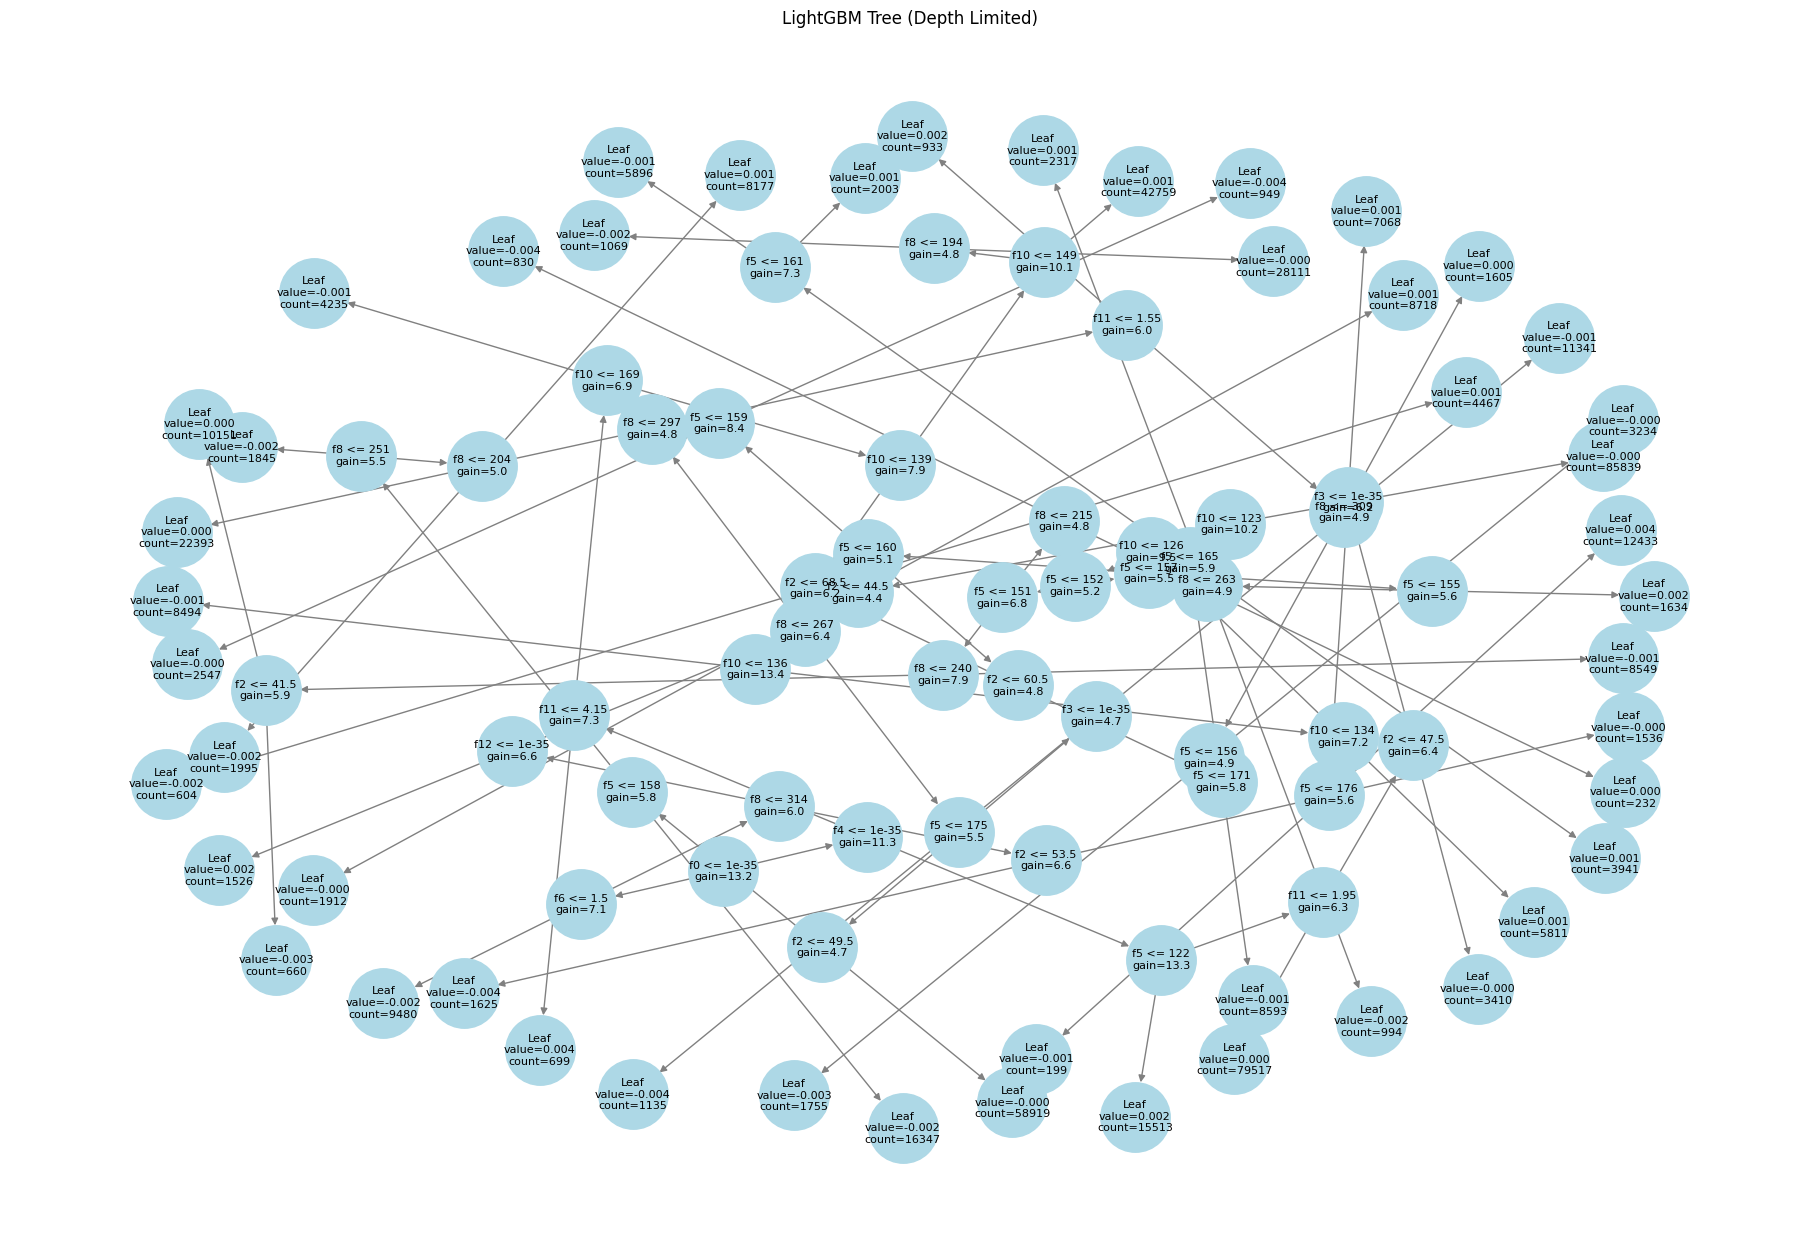

In [38]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_lgb_tree(tree, max_depth=3):
    G = nx.DiGraph()
    labels = {}

    def walk(node, parent=None, depth=0):
        if depth > max_depth:
            return

        node_id = id(node)

        if "leaf_index" in node:
            label = f"Leaf\nvalue={node['leaf_value']:.3f}\ncount={node['leaf_count']}"
        else:
            label = (
                f"f{node['split_feature']} <= {node['threshold']:.3g}\n"
                f"gain={node['split_gain']:.1f}"
            )

        labels[node_id] = label
        G.add_node(node_id)

        if parent is not None:
            G.add_edge(parent, node_id)

        if "left_child" in node:
            walk(node["left_child"], node_id, depth + 1)
        if "right_child" in node:
            walk(node["right_child"], node_id, depth + 1)

    walk(tree["tree_structure"])

    pos = nx.nx_pydot.graphviz_layout(G, prog="dot") if False else nx.spring_layout(G, seed=42)

    plt.figure(figsize=(18, 12))
    nx.draw(
        G, pos,
        labels=labels,
        node_size=2500,
        node_color="lightblue",
        font_size=8,
        edge_color="gray"
    )
    plt.title("LightGBM Tree (Depth Limited)")
    plt.show()

plot_lgb_tree( booster.dump_model()["tree_info"][799], max_depth=20)

In [ ]:
#               precision    recall  f1-score   support

#            0       0.90      0.90      0.90     69509
#            1       0.88      0.87      0.88     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 1 done with ROC-AUC: 0.955548222586477
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69509
#            1       0.88      0.87      0.87     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 2 done with ROC-AUC: 0.9545607642271182
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69509
#            1       0.88      0.87      0.88     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 3 done with ROC-AUC: 0.9553328255739608
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69509
#            1       0.88      0.87      0.87     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 4 done with ROC-AUC: 0.9548917821824026
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69510
#            1       0.88      0.87      0.88     56490

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 5 done with ROC-AUC: 0.9557331318215955

# CV Results (mean ± std):
# ACCURACY  : 0.8885 ± 0.0009
# ROC_AUC   : 0.9552 ± 0.0004
# PRECISION : 0.8818 ± 0.0006
# RECALL    : 0.8676 ± 0.0020
# F1        : 0.8746 ± 0.0012

# Average feature importances:
# Max HR                     9480.0
# Cholesterol                6978.0
# Age                        5475.4
# BP                         3936.0
# ST depression              3456.4
# Number of vessels fluro    1808.0
# Chest pain type            1704.4
# Sex                        1115.0
# Exercise angina            1029.4
# Slope of ST                 884.0
# Thallium                    859.4
# EKG results                 669.0
# FBS over 120                205.0
# dtype: float64

Number of under-predicted positives: 36631
Total number of positives: 282454
Fraction of positives under-predicted: 0.1297
Sample of under-predicted positive cases:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,target
70,64,0,3,120,211,0,0,162,0,0.0,1,0,7,1
72,54,1,3,112,226,0,0,156,0,1.2,2,1,3,1
82,52,1,4,125,263,0,2,174,0,1.6,3,0,3,1
94,51,1,3,118,254,0,2,154,0,0.6,1,0,7,1
106,64,0,4,110,274,0,2,170,0,0.6,1,0,6,1


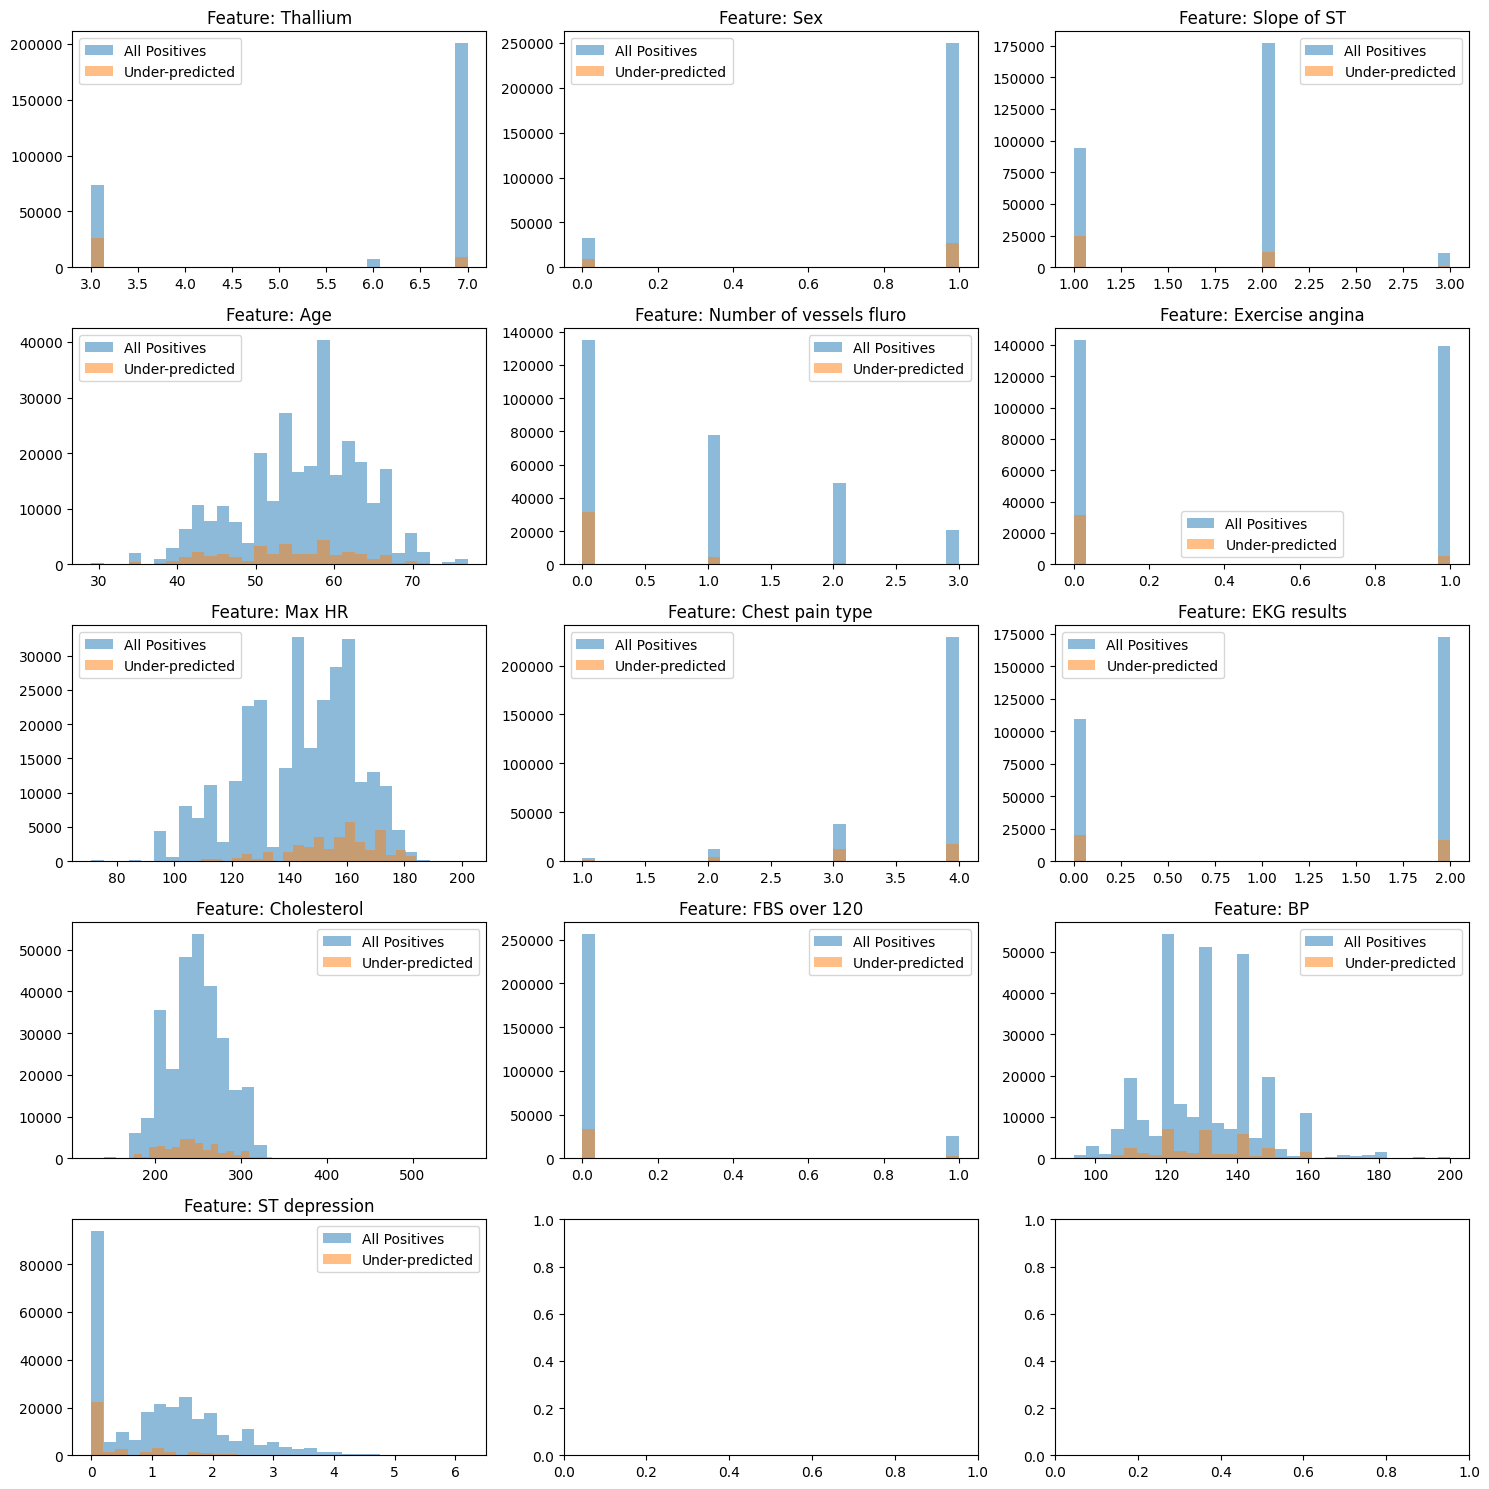

In [206]:
# Analyze under-predictions in X_res_oof (predicted probability < 0.2, but true target == 1)
threshold = 0.5
under_pred_idx = (X_res_oof < threshold) & (y.values == 1)
under_pred_count = under_pred_idx.sum()
total_true_positives = (y.values == 1).sum()

print(f"Number of under-predicted positives: {under_pred_count}")
print(f"Total number of positives: {total_true_positives}")
print(f"Fraction of positives under-predicted: {under_pred_count / total_true_positives:.4f}")

# Show some examples
under_pred_examples = df.loc[under_pred_idx]
print("Sample of under-predicted positive cases:")
display(under_pred_examples.head())

# Compare feature distributions for under-predicted vs. all positives
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(num_cols)//3 + 1, 3, figsize=(15, 15))
for idx, col in enumerate(num_cols):
    axes[idx//3, idx%3].hist(df.loc[(y.values == 1), col], bins=30, alpha=0.5, label='All Positives')
    axes[idx//3, idx%3].hist(under_pred_examples[col], bins=30, alpha=0.5, label='Under-predicted')
    axes[idx//3, idx%3].set_title(f"Feature: {col}")
    axes[idx//3, idx%3].legend()
plt.tight_layout()
plt.show()

In [ ]:
import itertools

# Visualize feature x feature interactions for under-predicted positives vs all positives


features = num_cols  # already defined as list of feature names

# Select a subset of feature pairs for visualization (e.g., top 5 important features)
top_features = importance_mean.head(5).index.tolist()
feature_pairs = list(itertools.combinations(top_features, 2))

import matplotlib.pyplot as plt

for f1, f2 in feature_pairs:
    plt.figure(figsize=(8, 6))
    plt.scatter(
        df.loc[(y.values == 1), f1],
        df.loc[(y.values == 1), f2],
        alpha=0.1, label='All Positives', s=5, color='C0'
    )
    plt.scatter(
        under_pred_examples[f1],
        under_pred_examples[f2],
        alpha=0.3, label='Under-predicted', s=5, color='C1'
    )
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f'Feature Interaction: {f1} vs {f2}')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [184]:
sub_df.to_parquet(r'submission04.parquet', index = False)

In [ ]:
# sub 00 

# CV Results (mean ± std):
# ACCURACY  : 0.8884 ± 0.0008
# ROC_AUC   : 0.9551 ± 0.0004
# PRECISION : 0.8816 ± 0.0004
# RECALL    : 0.8675 ± 0.0020
# F1        : 0.8745 ± 0.0010

# LB        : 0.95323

In [197]:
under_pred_examples['target'].value_counts()

target
1    36631
Name: count, dtype: int64

In [212]:
under_pred_examples.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'target'],
      dtype='object')

In [225]:
train[['ST depression','Heart Disease']].value_counts()

ST depression  Heart Disease
0.00           Absence          230116
               Presence          84823
1.60           Presence          19911
1.20           Presence          19569
1.40           Presence          18936
                                 ...  
0.06           Presence              1
2.12           Presence              1
1.64           Absence               1
5.40           Absence               1
5.90           Presence              1
Name: count, Length: 122, dtype: int64

In [227]:
train['ST depression'].describe()

count    630000.000000
mean          0.716028
std           0.948472
min           0.000000
25%           0.000000
50%           0.100000
75%           1.400000
max           6.200000
Name: ST depression, dtype: float64

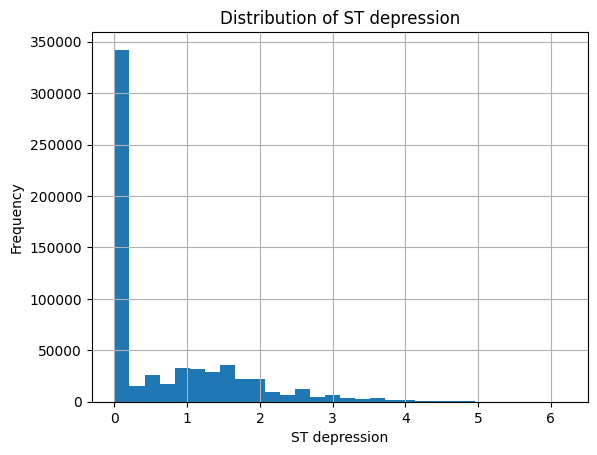

In [101]:
TARGET = 'Heart Disease'
CAT_COLS   = [
    'Sex', 
    'Chest pain type', 
    'FBS over 120', 
    'EKG results', 
    'Exercise angina', 
    'Slope of ST', 
    'Number of vessels fluro', 
    'Thallium'
] 
NUM_COLS   = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

for i in CAT_COLS:
    print('---------------')
    print(train[i].value_counts())

---------------
Sex
1    450283
0    179717
Name: count, dtype: int64
---------------
Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64
---------------
FBS over 120
0    579608
1     50392
Name: count, dtype: int64
---------------
EKG results
0    320116
2    308562
1      1322
Name: count, dtype: int64
---------------
Exercise angina
0    457553
1    172447
Name: count, dtype: int64
---------------
Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64
---------------
Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64
---------------
Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64


In [106]:
eda.columns
eda[TARGET] = eda[TARGET].map({'Absence': 0, 'Presence': 1})

In [107]:
(eda['Age'] * eda['ST depression']).corr(eda['Heart Disease'])

np.float64(0.43911034644848)

In [108]:
(eda['Age']).corr(eda['Heart Disease'])

np.float64(0.21209131286269142)

In [109]:
(eda['ST depression']).corr(eda['Heart Disease'])

np.float64(0.4306405912515558)

In [183]:
print((eda['Age']**2 * np.log1p(eda['ST depression'])).corr(eda['Heart Disease']))
print((eda['Age'] * np.log1p(eda['ST depression'])).corr(eda['Heart Disease']))
print((np.log1p(eda['Age']) * np.log1p(eda['ST depression'])).corr(eda['Heart Disease']))
print((np.sqrt(eda['Age']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print((np.sqrt(eda['Age']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print(((eda['Age']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print(((eda['Thallium']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print(((eda['Age'])**0.5 * (eda['ST depression'])).corr(eda['Heart Disease']))

print("xx")
print(((eda['Thallium'])**0.5 * (eda['ST depression'])).corr(eda['Heart Disease']))

print((np.log1p(eda['Thallium'])).corr(eda['Heart Disease']))
print(((eda['Thallium'])).corr(eda['Heart Disease']))
print(((eda['Thallium']) * np.log1p(eda['ST depression'])).corr(eda['Heart Disease'])) # -- 0.5198690733942132
print(((eda['Thallium']) * (eda['Age'])**0.5).corr(eda['Heart Disease'])) 
print(((eda['Thallium'])**0.5 * (eda['Age'])).corr(eda['Heart Disease'])) 
print(((eda['Thallium']) * np.log1p(eda['ST depression']) * np.log1p(eda['Age'])).corr(eda['Heart Disease']))


0.44771815900261663
0.4514027723211994
0.4445067587750504
0.4368046867131314
0.4368046867131314
0.43911034644848
0.4908167846318111
0.4368046867131314
xx
0.4740376440068133
0.6058069893103024
0.6057763854486644
0.5198690733942132
0.6154148773491708
0.5729868218857301
0.5218104819958872
